# DP10 - Anouck Jansen

| | |
|---|---|
| **Opdrachtgever** | Isala Ziekenhuis Zwolle |
| **Data Scientist** | Anouck Jansen |
| **Dataset** | Sepsis ICU dataset - Isala / Windesheim |
| **Opleverdatum** | 08-06-2026 |


**Leertaken:**
* **AD1**           - Evaluation
* **MC1**           - Data mining
* **AD3**           - Ethiek & Maatschappij

---

## **AN1 - Business understanding**

### Businessvraag

#### Hoofdvraag
> Kunnen we op basis van klinische meetwaarden (vitale parameters en laboratoriumwaarden) vroegtijdig voorspellen of een IC-patiënt sepsis zal ontwikkelen?

#### Sub-doel: Fairness
Als onderdeel van de evaluatie wordt onderzocht in hoeverre het model gelijk presteert voor verschillende patiëntgroepen (leeftijd en geslacht), en wat de ethische implicaties zijn van eventuele prestatieverschillen.

### Aanleiding:

Sepsis is een levensbedreigende aandoening waarbij het lichaam overmatig reageert op een infectie, wat kan leiden tot orgaanfalen en overlijden. Jaarlijks overlijden wereldwijd meer dan 11 miljoen mensen aan sepsis. In Nederland worden jaarlijks tienduizenden patiënten opgenomen met sepsis, waarvan een significant deel op de Intensive Care (IC). Vroegtijdige herkenning en behandeling is de sleutel tot overleving: elke vertraging van één uur in de behandeling verhoogt de sterfte significant.

Het Isala ziekenhuis in Zwolle heeft als één van de grotere perifere ziekenhuizen van Nederland een drukbezette IC-afdeling. Verpleegkundigen en artsen monitoren continu tientallen vitale parameters en laboratoriumwaarden per patiënt. Het handmatig herkennen van vroegtijdige sepsissignalen in al deze data is een uitdagende taak, zeker bij hoge werkdruk.

Een voorspellend model dat automatisch en continu de kans op sepsis berekent op basis van beschikbare meetwaarden, kan het klinische personeel ondersteunen om eerder in te grijpen. Dit kan levens redden en ziekenhuisopnames verkorten.

### Datavraag
> Kan een classificatiemodel, getraind op klinische features (vitale parameters en laboratoriumwaarden) per uur, voorspellen of een patiënt in de komende uren sepsis ontwikkelt (SepsisLabel = 1)?

### Organisatorische context

Dit onderzoek wordt uitgevoerd in het kader van de differentiatieopdracht Data Science voor Hogeschool Windesheim, in samenwerking met het Isala Ziekenhuis te Zwolle. Het Isala is een topklinisch opleidingsziekenhuis met een grote IC-afdeling. Het model is bedoeld als decision support tool voor IC-verpleegkundigen en -artsen: het signaleert risicovolle patiënten, waarna de behandelaar zelf de beslissing neemt.

### Maatschappelijke context

* **Patiëntveiligheid:** Sepsis heeft een hoge mortaliteit. Een eerder en betrouwbaarder signaleringsmodel kan directe levensreddende impact hebben voor IC-patiënten.
* **Werkdruk zorgpersoneel:** IC-personeel opereert onder hoge werkdruk. Een AI-ondersteund vroegwaarschuwingssysteem kan prioritering in zorgverlening ondersteunen zonder het klinisch oordeel te vervangen.
* **Fairness:** Het model wordt getraind op data van patiënten met wisselende leeftijden en geslachten. Als het model systematisch slechter presteert voor bepaalde groepen (bijvoorbeeld oudere patiënten of vrouwen), kan dit leiden tot ongelijke zorg. Dit wordt expliciet geanalyseerd als sub-doel van dit onderzoek.
* **Privacy:** De gebruikte dataset bevat geanonimiseerde medische gegevens. In een echte ziekenhuisomgeving zijn medische gegevens bijzondere persoonsgegevens (AVG Artikel 9) en vereist verwerking een expliciete juridische grondslag.
* **Automation bias:** Er bestaat een risico dat zorgverleners te veel vertrouwen op de modeluitkomst en hun eigen klinisch oordeel minder inzetten. Het model dient uitdrukkelijk als ondersteuning, niet als vervanging.
* **Klasse-onbalans:** Slechts ~1,8% van de observaties in de dataset heeft een sepsislabel. Een model dat altijd 0 voorspelt behaalt al 98,2% accuracy, wat misleidend is. Dit vraagt om specifieke evaluatiemetrics.

### Juridische implicaties

* **AVG Artikel 9 – Bijzondere persoonsgegevens:** Medische gegevens zijn bijzondere persoonsgegevens. Verwerking is in principe verboden, tenzij aan strikte voorwaarden is voldaan (o.a. expliciete toestemming of wetenschappelijk onderzoek met adequate waarborgen). De gebruikte dataset is voor dit onderzoek geanonimiseerd en valt daarmee buiten de directe werking van de AVG.
* **AI Act – Hoog risico:** Medische AI-systemen die worden ingezet voor diagnose of behandelbeslissingen vallen onder de hoog-risicocategorie van de EU AI Act (Annex III). Dit betekent dat bij daadwerkelijke inzet in het ziekenhuis eisen gelden op het gebied van transparantie, robuustheid, menselijk toezicht en documentatie.
* **MDR (Medical Device Regulation):** Software die wordt gebruikt voor klinische besluitvorming kan kwalificeren als medisch hulpmiddel en valt dan onder de EU MDR-regelgeving, inclusief CE-markering.

### Stakeholders

* **Isala Ziekenhuis Zwolle** – Opdrachtgever
* **IC-verpleegkundigen en intensivisten** – Eindgebruikers van het model
* **IC-patiënten** – Degenen wiens zorg direct beïnvloed wordt
* **Hogeschool Windesheim** – Onderwijsinstelling en begeleidende partij
* **Ethische commissie ziekenhuis** – Toetst inzet van AI in klinische praktijk

### KSF & KPI's

**KSF**  
Ontwikkeling van een model dat vroegtijdig en betrouwbaar sepsis kan signaleren bij IC-patiënten op basis van klinische meetwaarden.

**KPI's**
* Een **AUROC ≥ 0.80** behalen op de testset
* Een **recall (sensitivity) ≥ 0.70** voor de klasse `SepsisLabel = 1` (sepsis detecteren is kritisch)
* **Precision ≥ 0.30** voor de klasse `SepsisLabel = 1` (te veel fout-positieven belasten het personeel)
* Het verschil in AUROC tussen geslachten en leeftijdsgroepen kleiner dan **0.05** (fairness sub-doel)

### Databron

De gebruikte dataset is afkomstig van de Isala opdracht aangeboden via Hogeschool Windesheim. De dataset bevat per patiënt per uur gemeten klinische parameters gedurende het IC-verblijf. De trainset bevat **1.399.302 observaties** van **36.336 unieke patiënten**. De testset bevat **152.908 observaties** van **4.000 unieke patiënten** (zonder sepsislabel).

Beschikbare features:
* **Vitale parameters:** HR, O2Sat, Temp, SBP, MAP, DBP, Resp, EtCO2
* **Laboratoriumwaarden:** BaseExcess, HCO3, FiO2, pH, PaCO2, SaO2, AST, BUN, Alkalinephos, Calcium, Chloride, Creatinine, Bilirubin_direct, Glucose, Lactate, Magnesium, Phosphate, Potassium, Bilirubin_total, TroponinI, Hct, Hgb, PTT, WBC, Fibrinogen, Platelets
* **Patiëntkenmerken:** Age, Gender, Unit1, Unit2, HospAdmTime, ICULOS
* **Target:** SepsisLabel (0 = geen sepsis, 1 = sepsis)

#### Vital signs
| Kolomnaam | Beschrijving | Eenheid |
|---|---|---|
| HR | Hartslag (Heart Rate) | beats per minute |
| O2Sat | Pulse oximetry | % |
| Temp | Temperature | °C |
| SBP | Systolic BP | mm Hg |
| MAP | Mean arterial pressure | mm Hg |
| DBP | Diastolic BP | mm Hg |
| Resp | Respiration rate | breaths per minute |
| EtCO2 | End tidal carbon dioxide | mm Hg |

#### Laboratory values
| Kolomnaam | Beschrijving | Eenheid |
|---|---|---|
| BaseExcess | Excess bicarbonate | mmol/L |
| HCO3 | Bicarbonate | mmol/L |
| FiO2 | Fraction of inspired oxygen | 0–1 |
| pH | Zuurgraad van het bloed | — |
| PaCO2 | Partial pressure of carbon dioxide from arterial blood | mm Hg |
| SaO2 | Oxygen saturation from arterial blood | % |
| AST | Aspartate transaminas | IU/L |
| BUN | Blood urea nitrogen | mg/dL |
| Alkalinephos | Alkaline phosphatase | IU/L |
| Calcium | Calcium | mg/dL |
| Chloride | Chloride | mmol/L |
| Creatinine | Creatinine | mg/dL |
| Bilirubin_direct | Direct bilirubin | mg/dL |
| Bilirubin_total | Total bilirubin | mg/dL |
| Glucose | Serum glucos | mg/dL |
| Lactate | Lactic acid | mmol/L |
| Magnesium | Magnesium | mmol/L |
| Phosphate | Phosphate | mg/dL |
| Potassium | Potassiam | mmol/L |
| TroponinI | Troponin  | ng/mL |
| Hct | Hematocrit  | % |
| Hgb | Hemoglobin  | g/dL |
| PTT | Partial thromboplastin time  | seconds |
| WBC | Leukocyte coun | count/L |
| Fibrinogen | Fibrinogen concentration | mg/dL |
| Platelets | Platelet count | count/mL |

#### Patiënt- en opnamegegevens
| Kolomnaam | Beschrijving | Type |
|---|---|---|
| Age | Age | years |
| Gender | Geslacht | Binair Binair (0;female/1;male)|
| Unit1 | Administrative identifier for ICU unit (MICU) | Binair (0;false/1;true) |
| Unit2 | Administrative identifier for ICU unit (SICU) | Binair (0;false/1;true) |
| HospAdmTime | Time between hospital and ICU admission | Hours since ICU admission |
| ICULOS | ICU length of stay | hours since ICU admission |
| Hour | Uur van de observatie | Numeriek |

#### Target variabele
| Kolomnaam | Beschrijving |
|---|---|
| SepsisLabel | 0 = geen sepsis, 1 = sepsis aanwezig op dit meetmoment |

---

## **AN2 - Data Understanding**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from pathlib import Path

In [2]:
df_train = pd.read_csv('train_data.csv')
df_test  = pd.read_csv('test_data.csv')

print(f'Trainset: {df_train.shape[0]:,} rijen, {df_train.shape[1]} kolommen')
print(f'Testset:  {df_test.shape[0]:,} rijen, {df_test.shape[1]} kolommen')
df_train.head(10)

Trainset: 1,399,302 rijen, 44 kolommen
Testset:  152,908 rijen, 43 kolommen


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072
5,5,5,62.0,100.0,NaN,124.0,85.0,61.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,6,0,17072
6,6,6,61.0,100.0,NaN,101.0,75.0,58.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,7,0,17072
7,7,7,68.0,100.0,35.78,142.0,93.5,78.0,16.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,8,0,17072
8,8,8,71.0,100.0,NaN,121.0,74.0,91.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,9,0,17072
9,9,9,69.0,100.0,NaN,120.0,79.0,98.0,14.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,10,0,17072


In [3]:
df_train.describe()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
count,1.399302e+06,1.399302e+06,1.261070e+06,1.216615e+06,474304.000000,1.195492e+06,1.225052e+06,961600.000000,1.184880e+06,52020.000000,...,9319.000000,83243.000000,1.399302e+06,1.399302e+06,848885.000000,848885.000000,1.399294e+06,1.399302e+06,1.399302e+06,1.399302e+06
mean,2.551103e+01,2.551103e+01,8.459206e+01,9.719306e+01,36.977555,1.237281e+02,8.239274e+01,63.795128,1.873619e+01,32.925865,...,287.729520,195.940093,6.199812e+01,5.604073e-01,0.496395,0.503605,-5.614702e+01,2.700756e+01,1.821051e-02,5.917730e+04
std,2.884830e+01,2.884830e+01,1.734384e+01,2.945582e+00,0.773453,2.320404e+01,1.634168e+01,13.945080,5.098782e+00,7.931398,...,153.426372,104.158390,1.639975e+01,4.963377e-01,0.499987,0.499987,1.656790e+02,2.894534e+01,1.337120e-01,5.022381e+04
min,0.000000e+00,0.000000e+00,2.000000e+01,2.000000e+01,20.900000,2.000000e+01,2.000000e+01,20.000000,1.000000e+00,10.000000,...,34.000000,1.000000,1.400000e+01,0.000000e+00,0.000000,0.000000,-5.366860e+03,1.000000e+00,0.000000e+00,1.000000e+00
25%,9.000000e+00,9.000000e+00,7.200000e+01,9.600000e+01,36.500000,1.070000e+02,7.100000e+01,54.000000,1.500000e+01,28.000000,...,184.000000,126.000000,5.172000e+01,0.000000e+00,0.000000,0.000000,-4.675000e+01,1.100000e+01,0.000000e+00,9.996000e+03
50%,1.900000e+01,1.900000e+01,8.350000e+01,9.800000e+01,37.000000,1.210000e+02,8.000000e+01,62.000000,1.800000e+01,33.000000,...,251.000000,180.000000,6.400000e+01,1.000000e+00,0.000000,1.000000,-6.030000e+00,2.100000e+01,0.000000e+00,1.996200e+04
75%,3.300000e+01,3.300000e+01,9.600000e+01,9.950000e+01,37.500000,1.380000e+02,9.200000e+01,72.000000,2.150000e+01,38.000000,...,349.000000,244.000000,7.400000e+01,1.000000e+00,1.000000,1.000000,-4.000000e-02,3.400000e+01,0.000000e+00,1.098270e+05
max,3.350000e+02,3.350000e+02,2.800000e+02,1.000000e+02,50.000000,3.000000e+02,3.000000e+02,300.000000,1.000000e+02,100.000000,...,1760.000000,2322.000000,1.000000e+02,1.000000e+00,1.000000,1.000000,2.399000e+01,3.360000e+02,1.000000e+00,1.200000e+05


In de eerste tien rijen is al te zien dat de dataset veel missende waarden bevat, vooral bij laboratoriumwaarden. Dit is klinisch logisch: labtests worden niet elk uur afgenomen.

In [4]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1399302 entries, 0 to 1399301
Data columns (total 44 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1399302 non-null  int64  
 1   Hour              1399302 non-null  int64  
 2   HR                1261070 non-null  float64
 3   O2Sat             1216615 non-null  float64
 4   Temp              474304 non-null   float64
 5   SBP               1195492 non-null  float64
 6   MAP               1225052 non-null  float64
 7   DBP               961600 non-null   float64
 8   Resp              1184880 non-null  float64
 9   EtCO2             52020 non-null    float64
 10  BaseExcess        76344 non-null    float64
 11  HCO3              58809 non-null    float64
 12  FiO2              117251 non-null   float64
 13  pH                97571 non-null    float64
 14  PaCO2             78284 non-null    float64
 15  SaO2              48409 non-null    float64
 16  AST        

In [5]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 152908 entries, 0 to 152907
Data columns (total 43 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        152908 non-null  int64  
 1   Hour              152908 non-null  int64  
 2   HR                137741 non-null  float64
 3   O2Sat             132859 non-null  float64
 4   Temp              50922 non-null   float64
 5   SBP               130453 non-null  float64
 6   MAP               133888 non-null  float64
 7   DBP               104056 non-null  float64
 8   Resp              128995 non-null  float64
 9   EtCO2             5616 non-null    float64
 10  BaseExcess        7801 non-null    float64
 11  HCO3              6219 non-null    float64
 12  FiO2              12114 non-null   float64
 13  pH                10002 non-null   float64
 14  PaCO2             8017 non-null    float64
 15  SaO2              5152 non-null    float64
 16  AST               2379 non-null

In [6]:
missing_in_df_test = df_train.columns.difference(df_test.columns)
print(f"Columns in df_train but missing from df_test: {', '.join(missing_in_df_test)}")

# Columns in df_test but not in df_train
missing_in_df_train = df_test.columns.difference(df_train.columns)
print(f"Columns in df_test but missing from df_train: {', '.join(missing_in_df_train)}")

Columns in df_train but missing from df_test: SepsisLabel
Columns in df_test but missing from df_train: 


In [7]:
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
df_train.describe()


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
count,"1,399,302.00","1,399,302.00","1,261,070.00","1,216,615.00","474,304.00","1,195,492.00","1,225,052.00","961,600.00","1,184,880.00","52,020.00",...,"9,319.00","83,243.00","1,399,302.00","1,399,302.00","848,885.00","848,885.00","1,399,294.00","1,399,302.00","1,399,302.00","1,399,302.00"
mean,25.51,25.51,84.59,97.19,36.98,123.73,82.39,63.80,18.74,32.93,...,287.73,195.94,62.00,0.56,0.50,0.50,-56.15,27.01,0.02,"59,177.30"
std,28.85,28.85,17.34,2.95,0.77,23.20,16.34,13.95,5.10,7.93,...,153.43,104.16,16.40,0.50,0.50,0.50,165.68,28.95,0.13,"50,223.81"
min,0.00,0.00,20.00,20.00,20.90,20.00,20.00,20.00,1.00,10.00,...,34.00,1.00,14.00,0.00,0.00,0.00,"-5,366.86",1.00,0.00,1.00
25%,9.00,9.00,72.00,96.00,36.50,107.00,71.00,54.00,15.00,28.00,...,184.00,126.00,51.72,0.00,0.00,0.00,-46.75,11.00,0.00,"9,996.00"
50%,19.00,19.00,83.50,98.00,37.00,121.00,80.00,62.00,18.00,33.00,...,251.00,180.00,64.00,1.00,0.00,1.00,-6.03,21.00,0.00,"19,962.00"
75%,33.00,33.00,96.00,99.50,37.50,138.00,92.00,72.00,21.50,38.00,...,349.00,244.00,74.00,1.00,1.00,1.00,-0.04,34.00,0.00,"109,827.00"
max,335.00,335.00,280.00,100.00,50.00,300.00,300.00,300.00,100.00,100.00,...,"1,760.00","2,322.00",100.00,1.00,1.00,1.00,23.99,336.00,1.00,"120,000.00"


In [8]:
df_test.describe()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,Patient_ID
count,"152,908.00","152,908.00","137,741.00","132,859.00","50,922.00","130,453.00","133,888.00","104,056.00","128,995.00","5,616.00",...,"9,619.00",923.00,"8,966.00","152,908.00","152,908.00","91,365.00","91,365.00","152,908.00","152,908.00","152,908.00"
mean,25.33,25.33,84.48,97.20,36.97,123.96,82.47,64.16,18.64,33.25,...,11.40,283.91,196.70,62.11,0.55,0.50,0.50,-55.92,26.88,"59,422.72"
std,29.19,29.19,17.15,2.86,0.74,23.48,16.34,14.05,5.09,8.13,...,6.72,148.70,98.65,16.26,0.50,0.50,0.50,126.72,29.55,"50,470.40"
min,0.00,0.00,23.00,20.00,30.00,20.00,20.00,20.00,1.00,10.00,...,0.10,35.00,8.00,17.00,0.00,0.00,0.00,"-1,692.18",1.00,2.00
25%,9.00,9.00,72.00,96.00,36.50,107.00,71.00,54.00,15.00,28.50,...,7.60,181.00,131.00,51.05,0.00,0.00,0.00,-49.13,11.00,"9,862.00"
50%,19.00,19.00,83.50,98.00,37.00,121.00,80.00,62.00,18.00,34.00,...,10.30,242.00,182.00,64.00,1.00,0.00,1.00,-6.01,21.00,"20,309.00"
75%,33.00,33.00,95.00,99.00,37.50,139.00,92.00,72.00,21.00,38.50,...,13.80,350.00,242.00,74.21,1.00,1.00,1.00,-0.04,34.00,"110,348.00"
max,335.00,335.00,194.00,100.00,41.60,296.00,298.00,296.00,100.00,99.00,...,166.20,912.00,"1,111.00",100.00,1.00,1.00,1.00,9.05,336.00,"119,960.00"


### Klasse-verdeling (SepsisLabel)

=== Klasse-verdeling SepsisLabel ===
Geen sepsis (0):  1,373,820  (98.18%)
Sepsis     (1):     25,482  (1.82%)
Verhouding 0:1 = 53:1


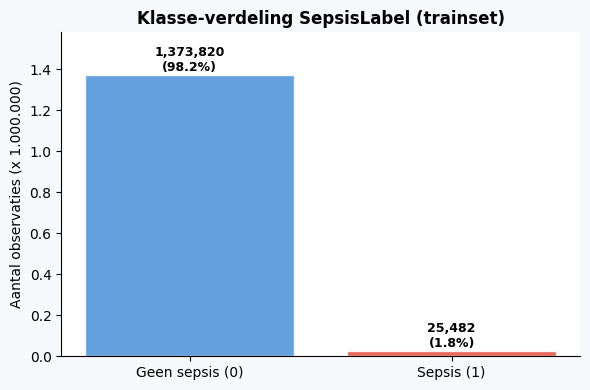

In [9]:
label_counts = df_train['SepsisLabel'].value_counts()
label_pct    = df_train['SepsisLabel'].value_counts(normalize=True).round(4) * 100

print('=== Klasse-verdeling SepsisLabel ===')
print(f'Geen sepsis (0): {label_counts[0]:>10,}  ({label_pct[0]:.2f}%)')
print(f'Sepsis     (1): {label_counts[1]:>10,}  ({label_pct[1]:.2f}%)')
print(f'Verhouding 0:1 = {label_counts[0]//label_counts[1]}:1')

fig, ax = plt.subplots(figsize=(6, 4), facecolor='#f7f9fc')
bars = ax.bar(['Geen sepsis (0)', 'Sepsis (1)'], label_counts.values,
              color=['#4a90d9', '#e74c3c'], edgecolor='white', alpha=0.85)
for bar, val, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, max(label_counts.values) * 1.15)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x / 1_000_000:,.1f}"))
ax.set_title('Klasse-verdeling SepsisLabel (trainset)', fontsize=12, fontweight='bold')
ax.set_ylabel('Aantal observaties (x 1.000.000)')
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Er is een sterke **klasse-onbalans**: slechts 1,82% van de observaties heeft een sepsislabel. Een naïef model dat altijd 0 voorspelt behaalt al 98,18% accuracy. Dit maakt accuracy een ongeschikte metric; we focussen op AUROC, recall en precision.

### Missende waarden

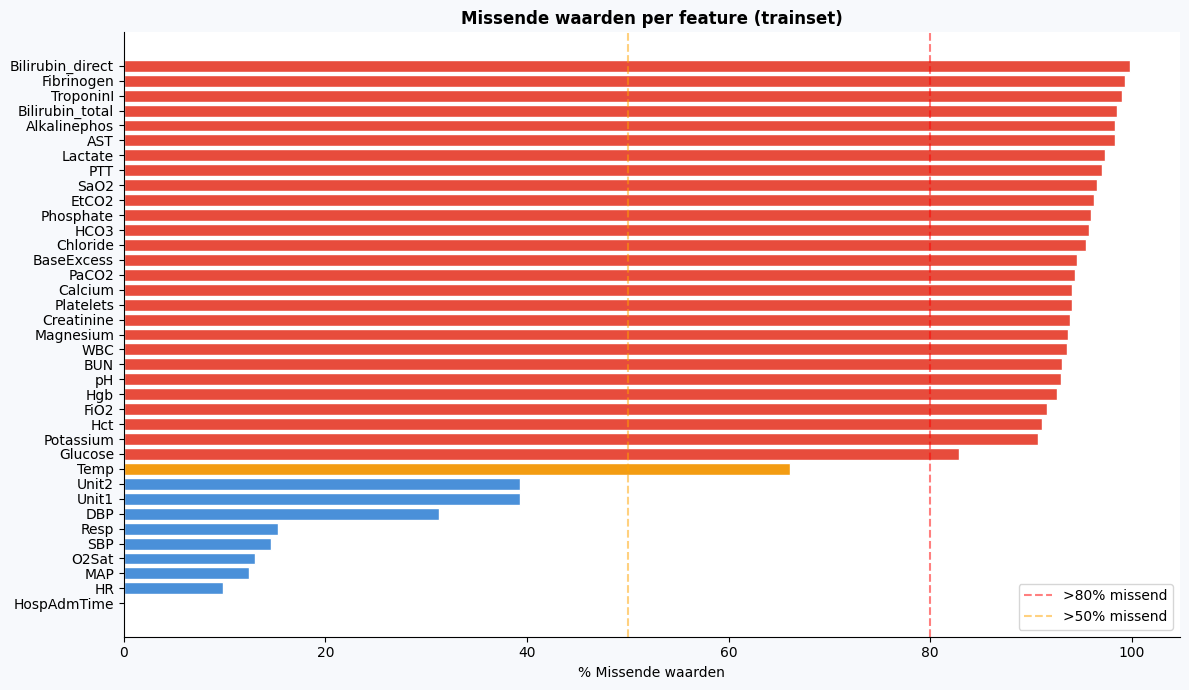

Features met > 80% missende waarden: 27
Features met 50% - 80% missende waarden : 1
Features met < 50% missende waarden (> 0%): 9
Features zonder missende waarden : 7


In [10]:
missing = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['Feature', 'Missing (%)']

fig, ax = plt.subplots(figsize=(12, 7), facecolor='#f7f9fc')
colors = ['#e74c3c' if v > 80 else '#f39c12' if v > 50 else '#4a90d9' 
          for v in missing_df['Missing (%)']]
ax.barh(missing_df['Feature'][::-1], missing_df['Missing (%)'][::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(x=80, color='red', linestyle='--', alpha=0.5, label='>80% missend')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='>50% missend')
ax.set_xlabel('% Missende waarden')
ax.set_title('Missende waarden per feature (trainset)', fontsize=12, fontweight='bold')
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Features met > 80% missende waarden: {(missing > 80).sum()}')
print(f'Features met 50% - 80% missende waarden : {((missing > 50) & (missing <= 80)).sum()}')
print(f'Features met < 50% missende waarden (> 0%): {((missing > 0) & (missing <= 50)).sum()}')
print(f'Features zonder missende waarden : {(missing == 0).sum()}')

De meeste laboratoriumwaarden hebben een hoog percentage missende waarden. Dit is klinisch realistisch: laboratoriumtests worden niet elk uur afgenomen. Vitale parameters (HR, O2Sat, SBP, MAP, Resp) hebben minder missende waarden en worden continu gemonitord.

### Distributie vitale parameters

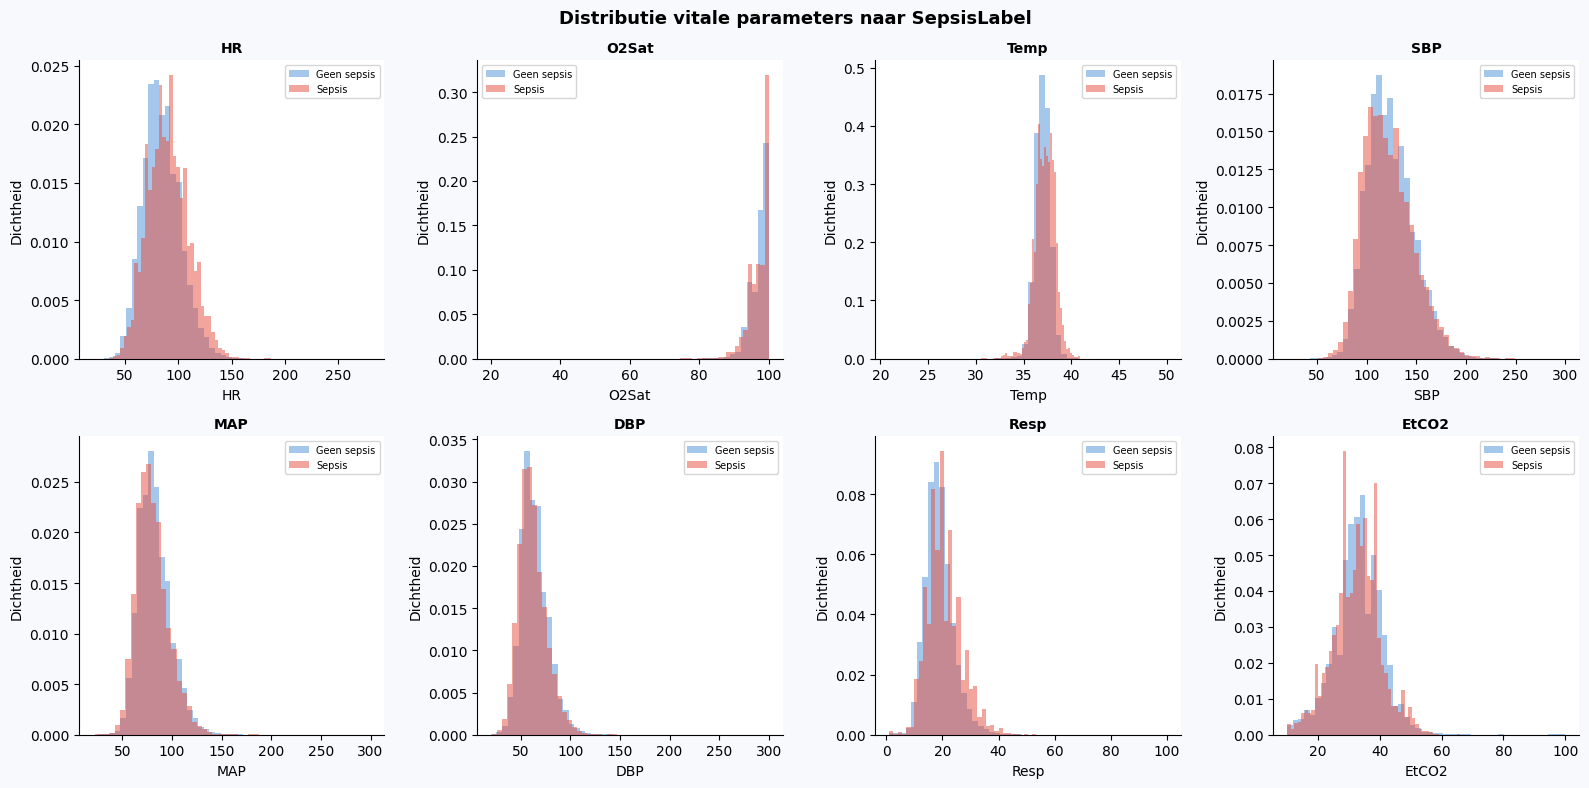

In [11]:
vital_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']

fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor='#f7f9fc')
fig.suptitle('Distributie vitale parameters naar SepsisLabel', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), vital_cols):
    for label, color, name in [(0, '#4a90d9', 'Geen sepsis'), (1, '#e74c3c', 'Sepsis')]:
        data = df_train[df_train['SepsisLabel'] == label][col].dropna()
        ax.hist(data, bins=50, alpha=0.5, color=color, label=name, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Dichtheid')
    ax.legend(fontsize=7)
    ax.set_facecolor('white')
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

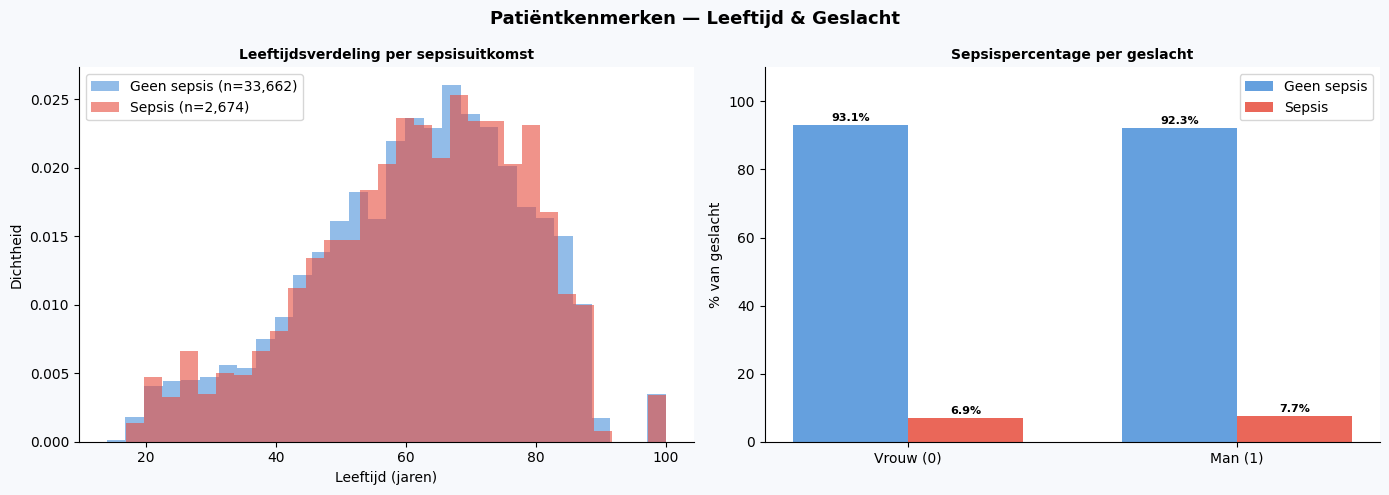

In [12]:
# Patiëntniveau: één rij per patiënt (eerste observatie)
df_patients = df_train.groupby('Patient_ID').first().reset_index()
df_patients['sepsis_patient'] = df_train.groupby('Patient_ID')['SepsisLabel'].max().values

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f7f9fc')
fig.suptitle('Patiëntkenmerken — Leeftijd & Geslacht', fontsize=13, fontweight='bold')

# Leeftijdsdistributie
ax = axes[0]
for label, color, name in [(0, '#4a90d9', 'Geen sepsis'), (1, '#e74c3c', 'Sepsis')]:
    data = df_patients[df_patients['sepsis_patient'] == label]['Age'].dropna()
    ax.hist(data, bins=30, alpha=0.6, color=color, label=f'{name} (n={len(data):,})', density=True)
ax.set_title('Leeftijdsverdeling per sepsisuitkomst', fontsize=10, fontweight='bold')
ax.set_xlabel('Leeftijd (jaren)')
ax.set_ylabel('Dichtheid')
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# Geslacht
ax = axes[1]
gender_sepsis = df_patients.groupby(['Gender', 'sepsis_patient']).size().unstack(fill_value=0)
gender_sepsis.index = ['Vrouw (0)', 'Man (1)']
gender_sepsis.columns = ['Geen sepsis', 'Sepsis']
gender_pct = gender_sepsis.div(gender_sepsis.sum(axis=1), axis=0) * 100
x = np.arange(2)
width = 0.35
bars_no  = ax.bar(x - width/2, gender_pct['Geen sepsis'], width, label='Geen sepsis', color='#4a90d9', alpha=0.85)
bars_sep = ax.bar(x + width/2, gender_pct['Sepsis'],      width, label='Sepsis',      color='#e74c3c', alpha=0.85)

# Percentage labels
for bar in bars_no:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars_sep:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['Vrouw (0)', 'Man (1)'])
ax.set_ylabel('% van geslacht')
ax.set_ylim(0, 110)
ax.set_title('Sepsispercentage per geslacht', fontsize=10, fontweight='bold')
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

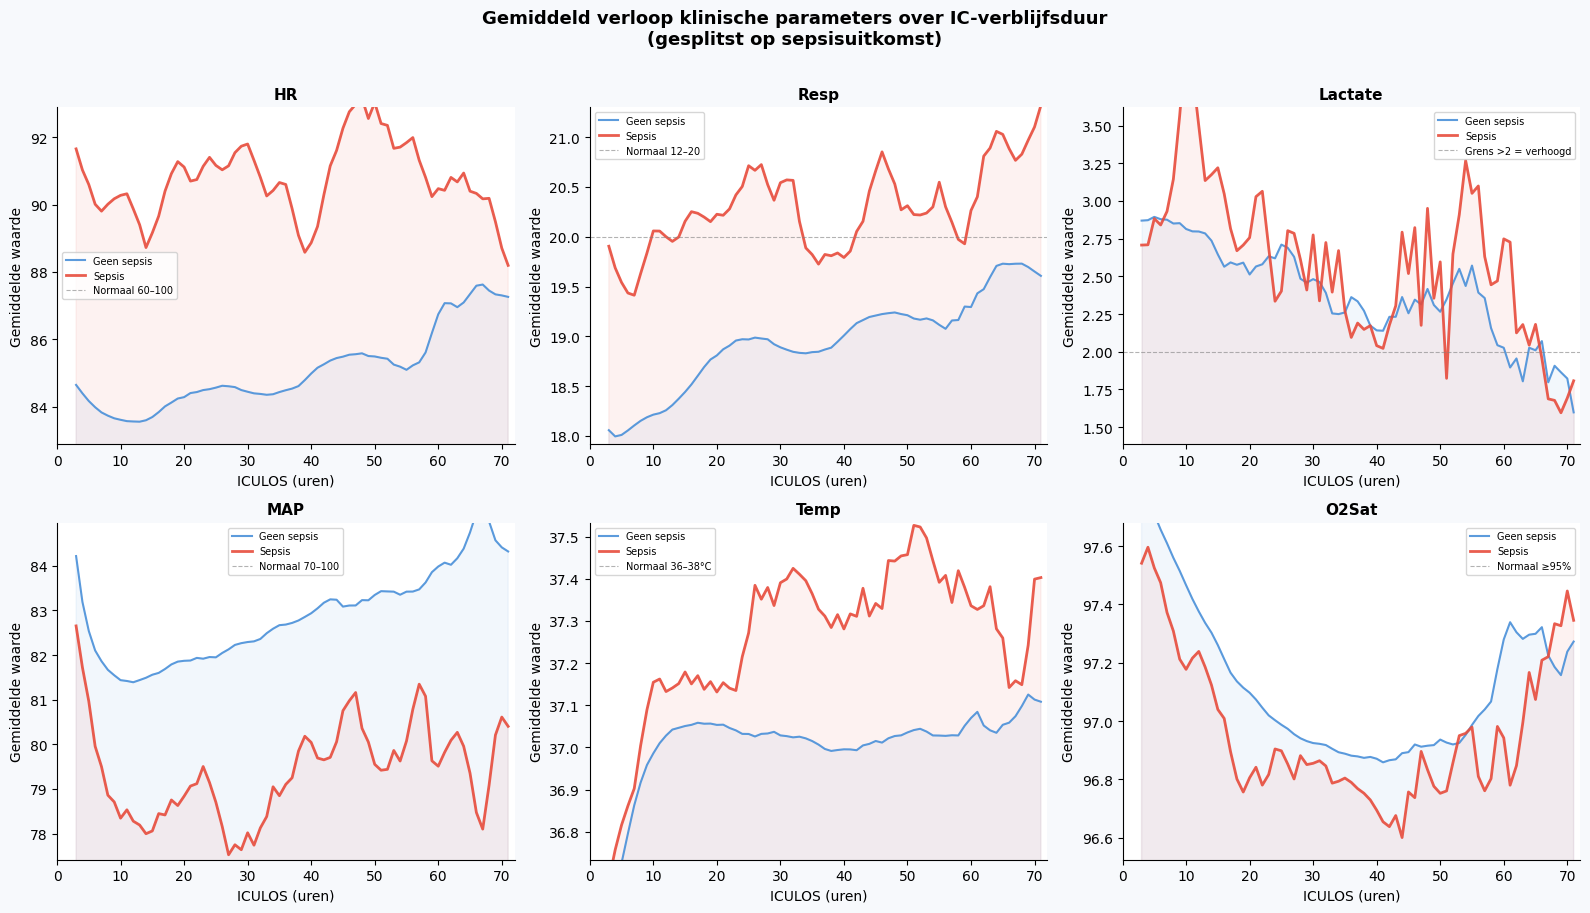

In [13]:
vitals_time = ['HR', 'Resp', 'Lactate', 'MAP', 'Temp', 'O2Sat']

df_time = df_train[df_train['ICULOS'] <= 72].copy()

trend = (
    df_time.groupby(['ICULOS', 'SepsisLabel'])[vitals_time]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), facecolor='#f7f9fc')
fig.suptitle('Gemiddeld verloop klinische parameters over IC-verblijfsduur\n(gesplitst op sepsisuitkomst)',
             fontsize=13, fontweight='bold', y=1.01)

reference_lines = {
    'HR':      (60, 100, 'Normaal 60–100'),
    'Resp':    (12, 20,  'Normaal 12–20'),
    'MAP':     (70, 100, 'Normaal 70–100'),
    'Temp':    (36, 38,  'Normaal 36–38°C'),
    'O2Sat':   (95, 100, 'Normaal ≥95%'),
    'Lactate': (None, 2, 'Grens >2 = verhoogd'),
}

for ax, col in zip(axes.flatten(), vitals_time):
    for label, color, name, lw in [(0, '#4a90d9', 'Geen sepsis', 1.5),
                                    (1, '#e74c3c', 'Sepsis',      2.0)]:
        subset = trend[trend['SepsisLabel'] == label]
        y = subset.set_index('ICULOS')[col].rolling(3, center=True).mean()
        ax.plot(y.index, y.values, color=color, linewidth=lw, label=name, alpha=0.9)
        ax.fill_between(y.index, y.values, alpha=0.07, color=color)

    if col in reference_lines:
        low, high, label_ref = reference_lines[col]
        if low is not None:
            ax.axhline(low, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.axhline(high, color='gray', linestyle='--', linewidth=0.8, alpha=0.6,
                   label=label_ref)

    # Automatische y-as op basis van data
    y_all = trend[col].dropna()
    y_min = y_all.quantile(0.05)
    y_max = y_all.quantile(0.95)
    margin = (y_max - y_min) * 0.10
    ax.set_ylim(y_min - margin, y_max + margin)

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('ICULOS (uren)')
    ax.set_ylabel('Gemiddelde waarde')
    ax.legend(fontsize=7)
    ax.set_facecolor('white')
    ax.set_xlim(0, 72)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### Correlatiematrices alle data groepen

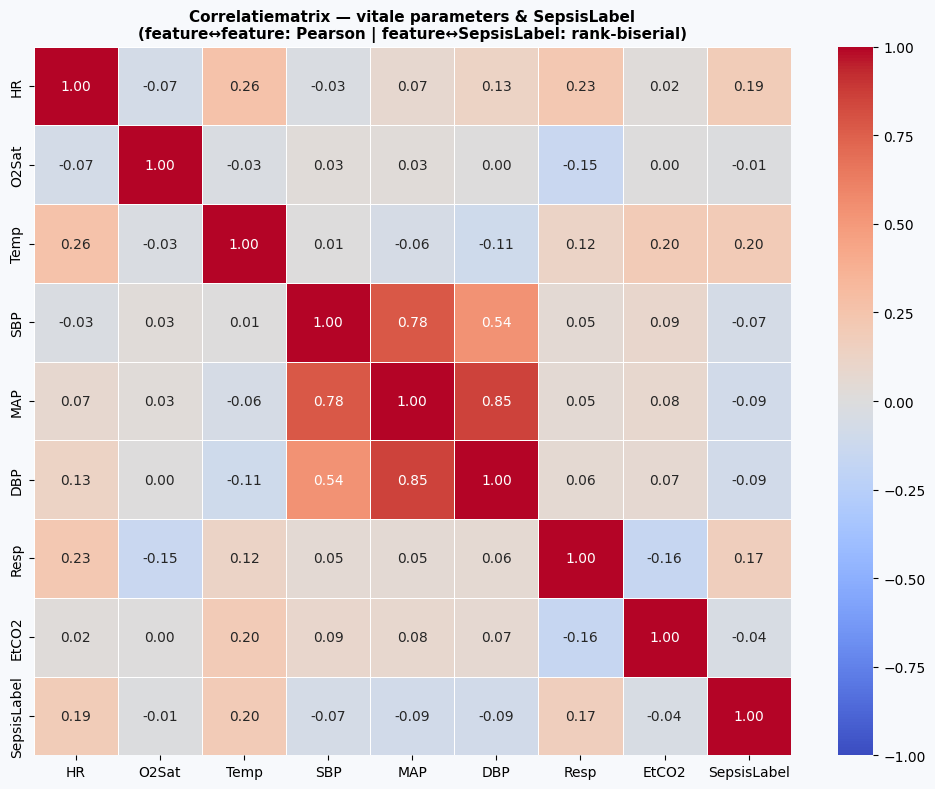

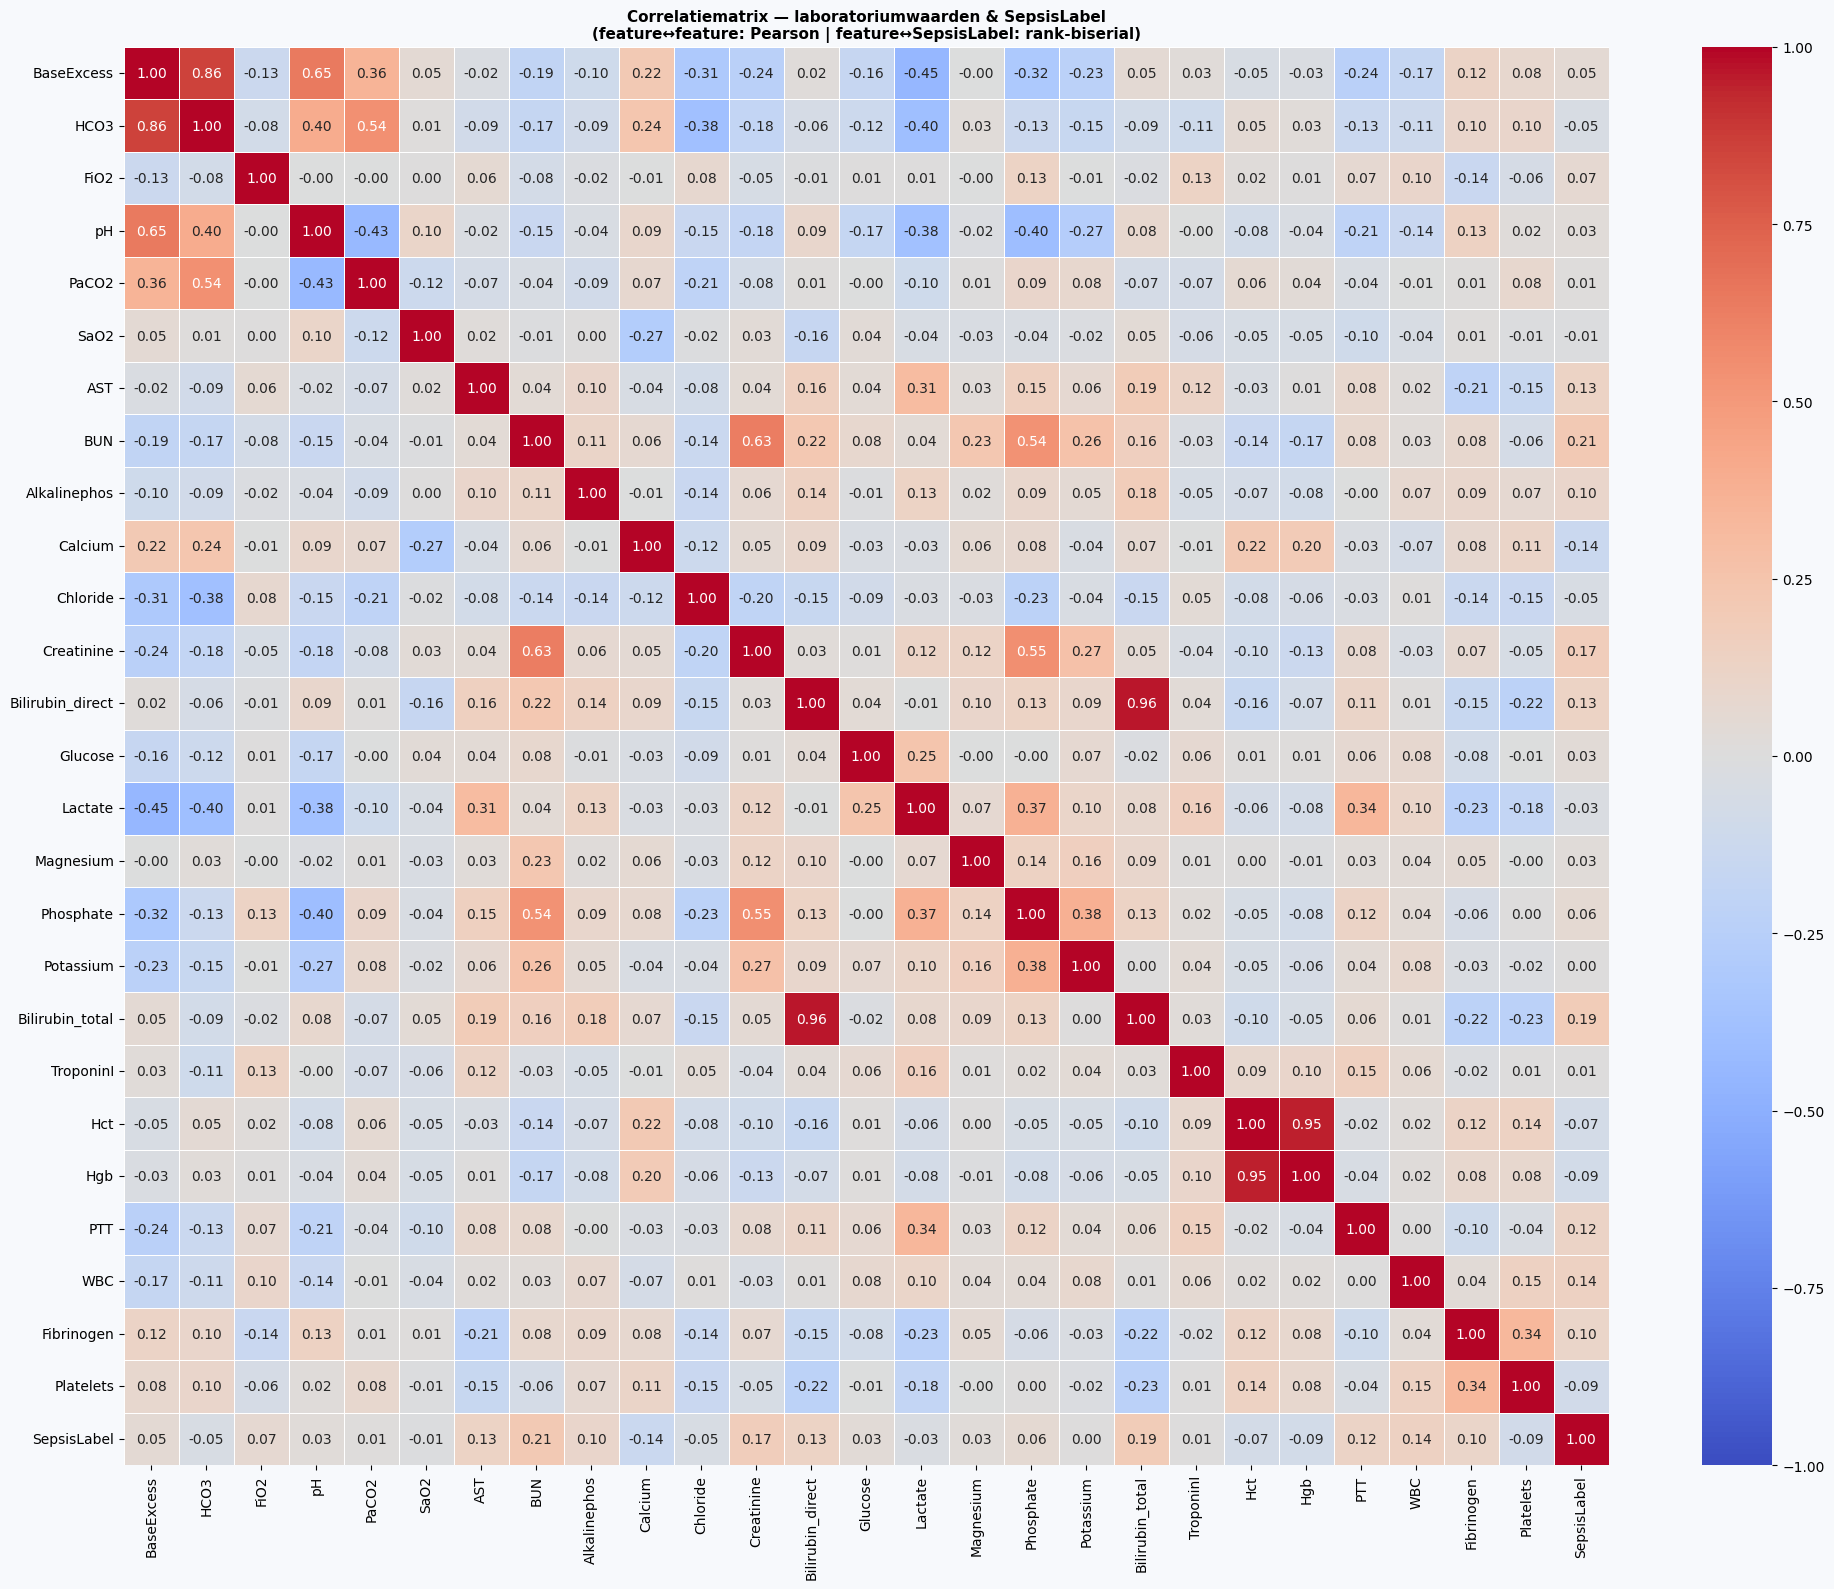

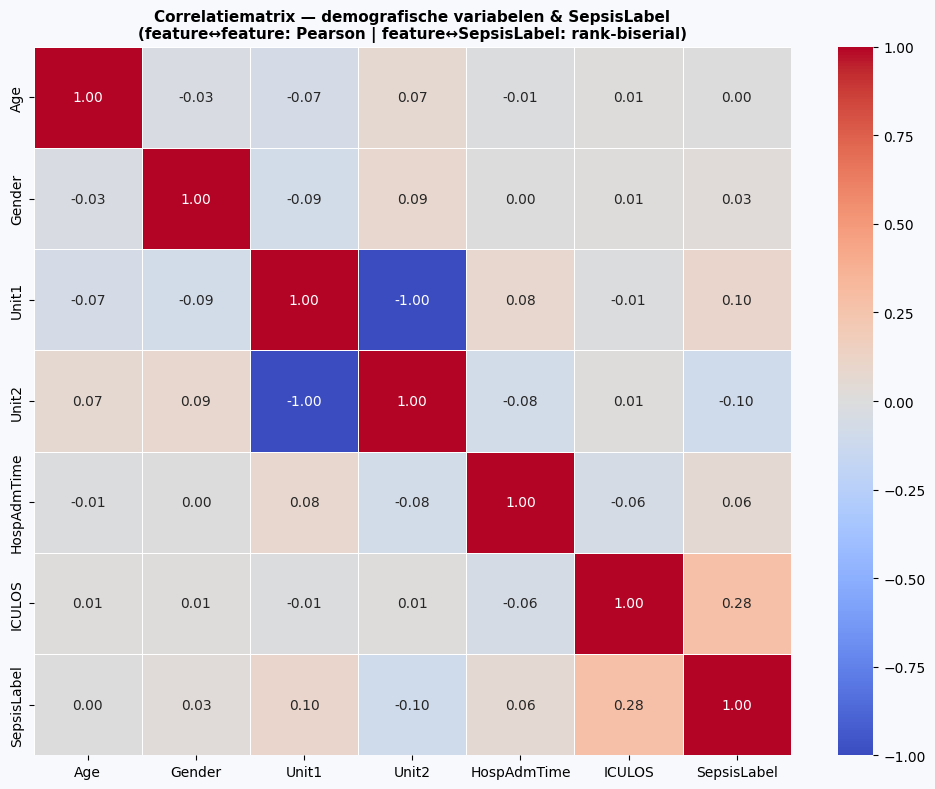

In [14]:
from sklearn.metrics import roc_auc_score

def corr_matrix_with_rb(df, cols, title, figsize):
    matrix = df[cols].corr()
    for col in cols:
        if col == 'SepsisLabel':
            matrix.loc[col, col] = 1.0
            continue
        valid = df[[col, 'SepsisLabel']].dropna()
        if len(valid) < 100:
            continue
        auc = roc_auc_score(valid['SepsisLabel'], valid[col])
        r_rb = 2 * (auc - 0.5)
        matrix.loc[col, 'SepsisLabel'] = r_rb
        matrix.loc['SepsisLabel', col] = r_rb
    fig, ax = plt.subplots(figsize=figsize, facecolor='#f7f9fc')
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=ax, linewidths=0.5, vmin=-1, vmax=1)
    ax.set_title(f'{title}\n(feature↔feature: Pearson | feature↔SepsisLabel: rank-biserial)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

vital_cols = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'SepsisLabel']
corr_matrix_with_rb(df_train, vital_cols, 'Correlatiematrix — vitale parameters & SepsisLabel', (10, 8))

lab_cols = ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos',
            'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate',
            'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct',
            'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'SepsisLabel']
corr_matrix_with_rb(df_train, lab_cols, 'Correlatiematrix — laboratoriumwaarden & SepsisLabel', (20, 16))

demo_cols = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']
corr_matrix_with_rb(df_train, demo_cols, 'Correlatiematrix — demografische variabelen & SepsisLabel', (10, 8))


### Correlatie sepsis met gemeten data

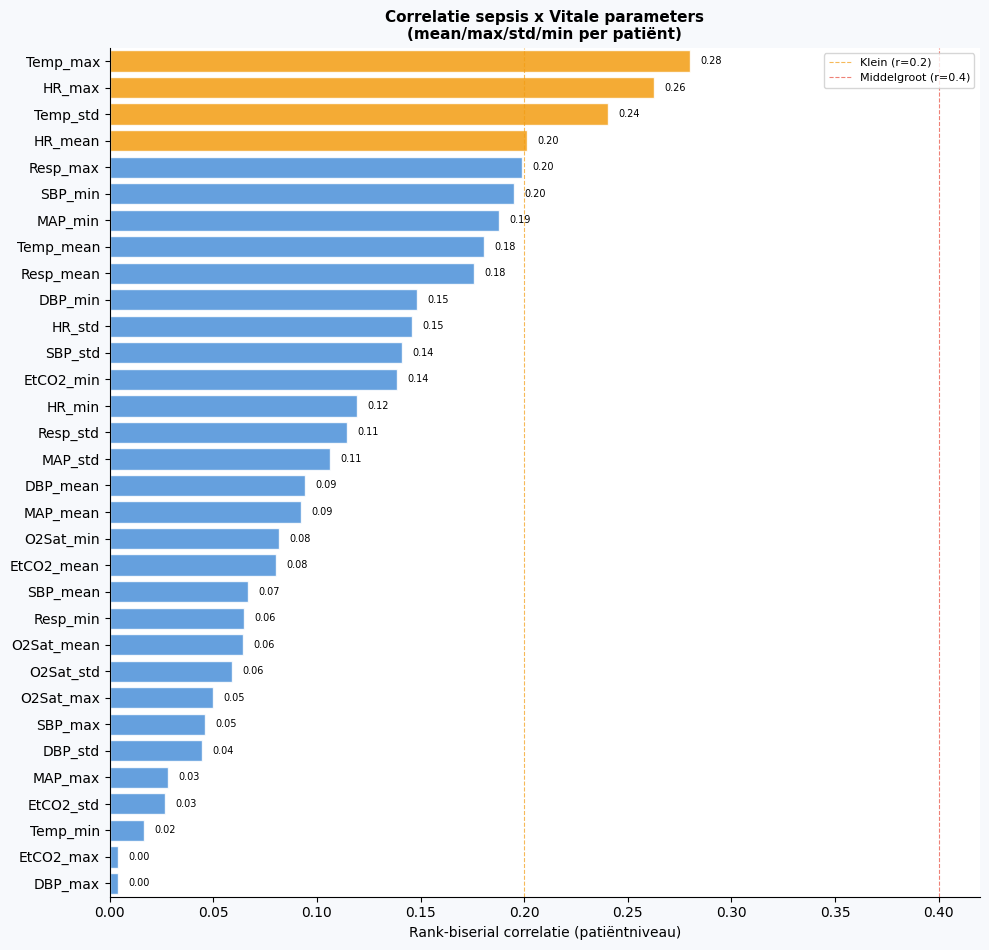

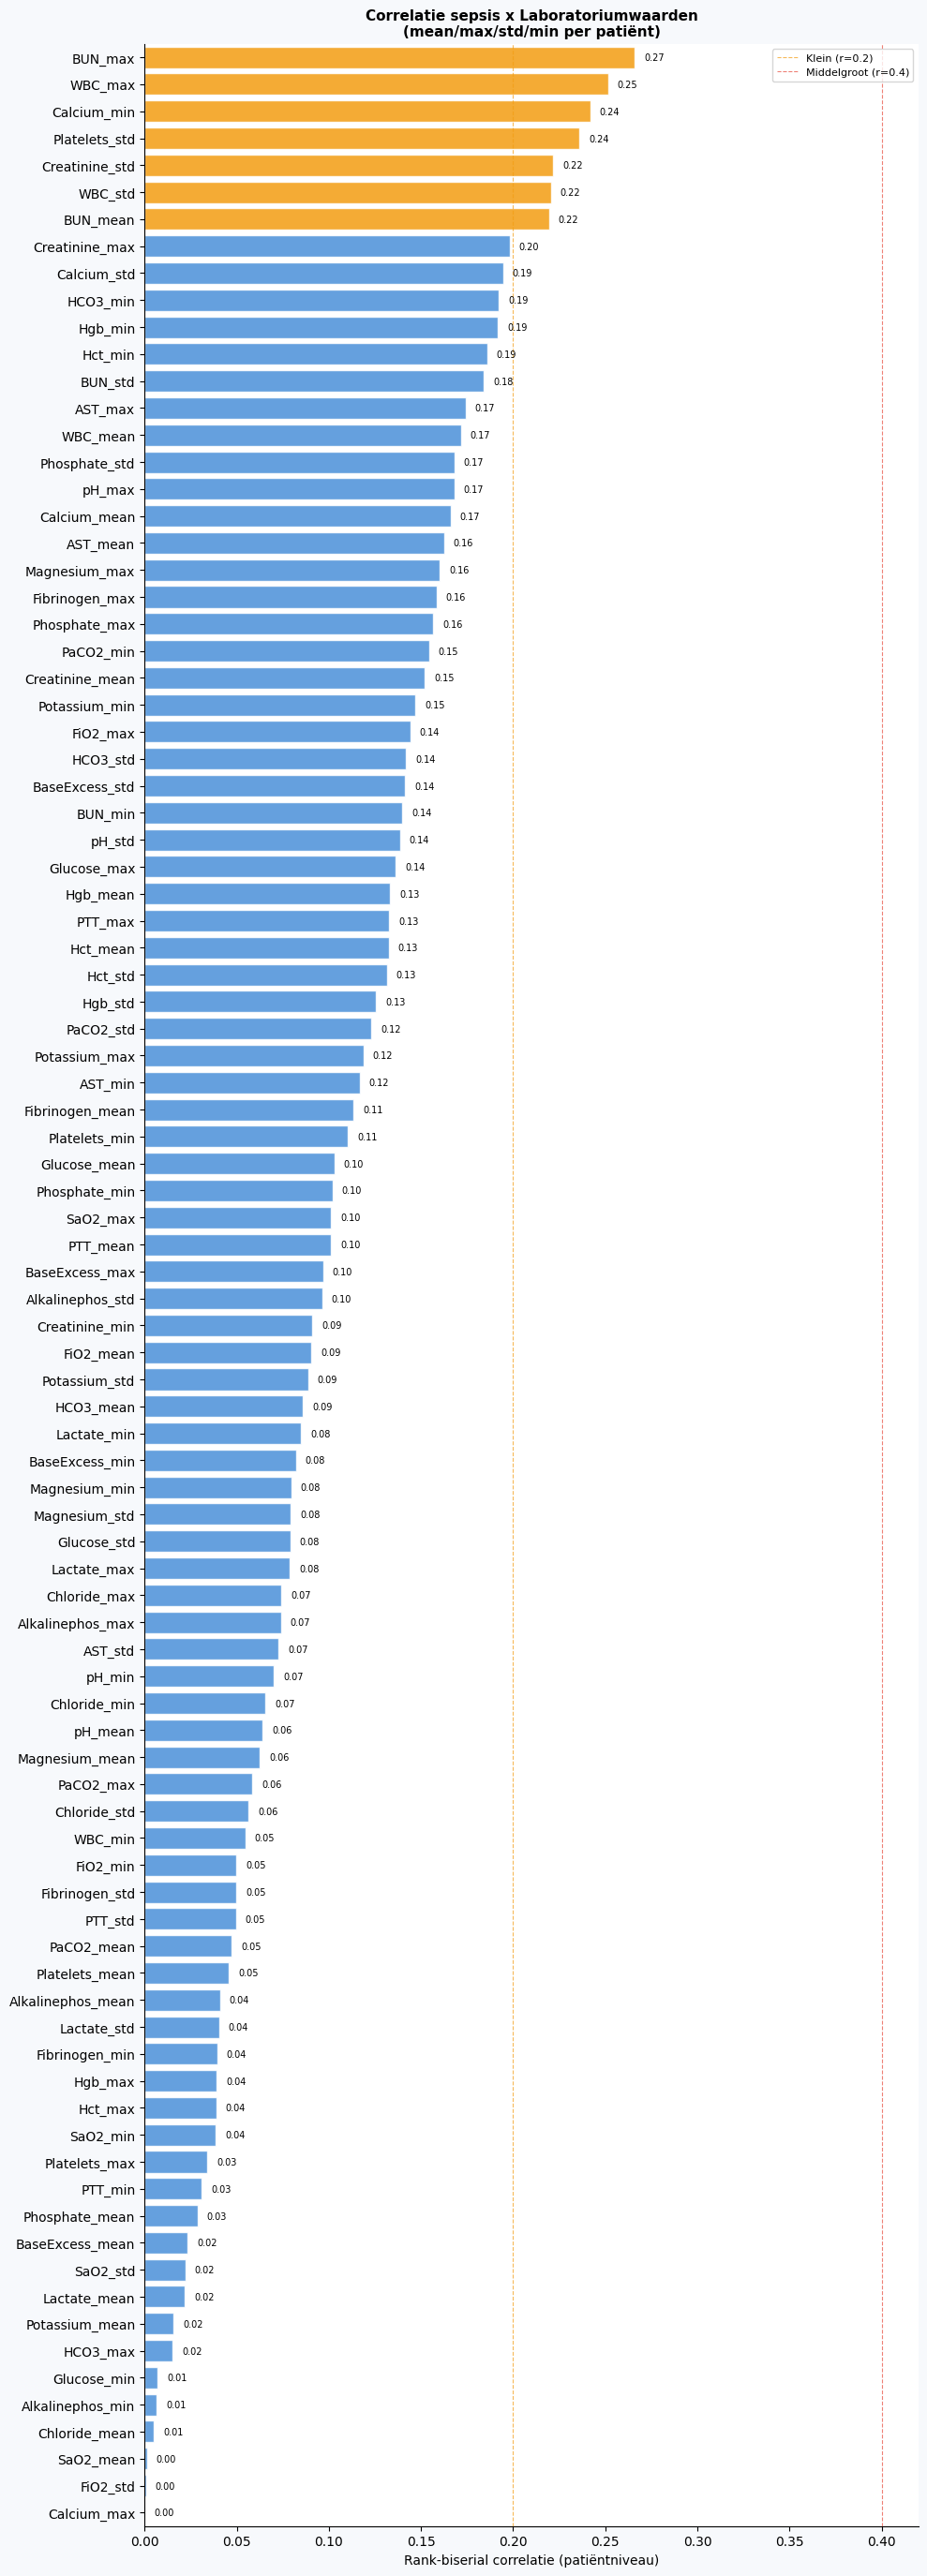

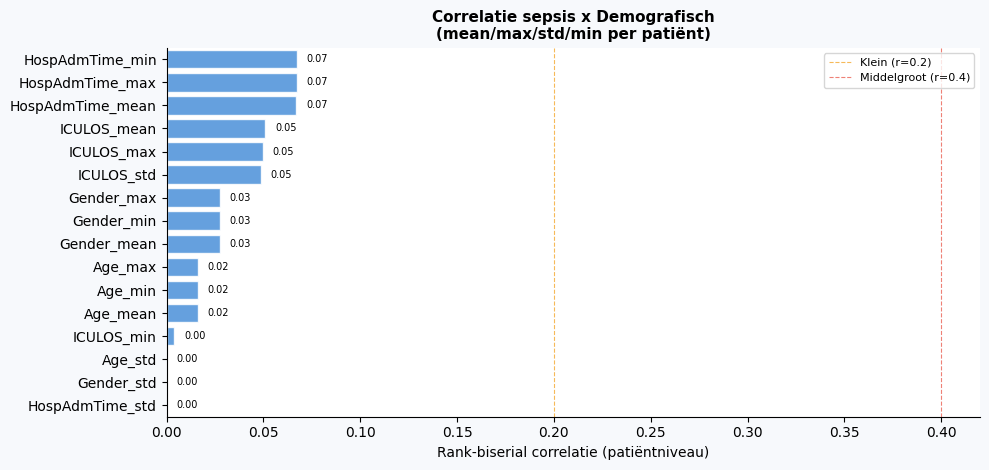

In [15]:
feature_groups = {
    'Vitale parameters': ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2'],
    'Laboratoriumwaarden': ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
                            'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Glucose',
                            'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Hct', 'Hgb',
                            'PTT', 'WBC', 'Fibrinogen', 'Platelets'],
    'Demografisch': ['Age', 'Gender', 'HospAdmTime', 'ICULOS'],
}

def cohens_d(g1, g2):
    pooled = np.sqrt(((len(g1)-1)*g1.std()**2 + (len(g2)-1)*g2.std()**2) / (len(g1)+len(g2)-2))
    return (g1.mean() - g2.mean()) / pooled if pooled > 0 else 0

# Patient-level aggregation
agg_dict = {col: ['mean', 'max', 'std', 'min']
            for cols in feature_groups.values() for col in cols}
agg_dict['SepsisLabel'] = 'max'

df_pat = df_train.groupby('Patient_ID').agg(agg_dict)
df_pat.columns = ['_'.join(c) for c in df_pat.columns]
df_pat = df_pat.rename(columns={'SepsisLabel_max': 'sepsis'}).reset_index()

sepsis_pat    = df_pat[df_pat['sepsis'] == 1]
no_sepsis_pat = df_pat[df_pat['sepsis'] == 0]

for group_name, cols in feature_groups.items():
    feature_cols = [f'{col}_{agg}' for col in cols for agg in ['mean', 'max', 'std', 'min']
                    if f'{col}_{agg}' in df_pat.columns]

    results = []
    for col in feature_cols:
        valid = df_pat[['sepsis', col]].dropna()
        if valid['sepsis'].nunique() < 2 or len(valid) < 50:
            continue
        auc = roc_auc_score(valid['sepsis'], valid[col])
        r_rb = 2 * (max(auc, 1-auc) - 0.5)
        d = abs(cohens_d(sepsis_pat[col].dropna(), no_sepsis_pat[col].dropna()))
        results.append({'feature': col, 'AUROC': max(auc, 1-auc), 'rank_biserial': r_rb, 'cohens_d': d})

    res_df = pd.DataFrame(results).sort_values('rank_biserial', ascending=False)

    fig, ax = plt.subplots(figsize=(10, max(4, len(res_df) * 0.3)), facecolor='#f7f9fc')
    colors = ['#e74c3c' if v >= 0.4 else '#f39c12' if v >= 0.2 else '#4a90d9'
              for v in res_df['rank_biserial']]
    ax.barh(res_df['feature'][::-1], res_df['rank_biserial'][::-1],
            color=colors[::-1], alpha=0.85, edgecolor='white')
    ax.set_ylim(-0.5, len(res_df) - 0.5)
    ax.axvline(0.2, color='#f39c12', linestyle='--', linewidth=0.8, alpha=0.7, label='Klein (r=0.2)')
    ax.axvline(0.4, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.7, label='Middelgroot (r=0.4)')
    for i, (_, row) in enumerate(res_df[::-1].iterrows()):
        ax.text(row['rank_biserial'] + 0.005, i, f"{row['rank_biserial']:.2f}",
                va='center', fontsize=7)
    ax.set_xlabel('Rank-biserial correlatie (patiëntniveau)')
    ax.set_title(f'Correlatie sepsis x {group_name}\n(mean/max/std/min per patiënt)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_facecolor('white')
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()


### Fairness — leeftijd & geslacht

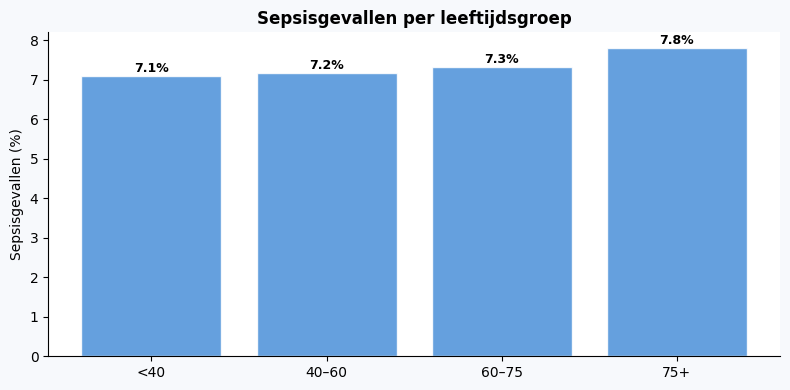

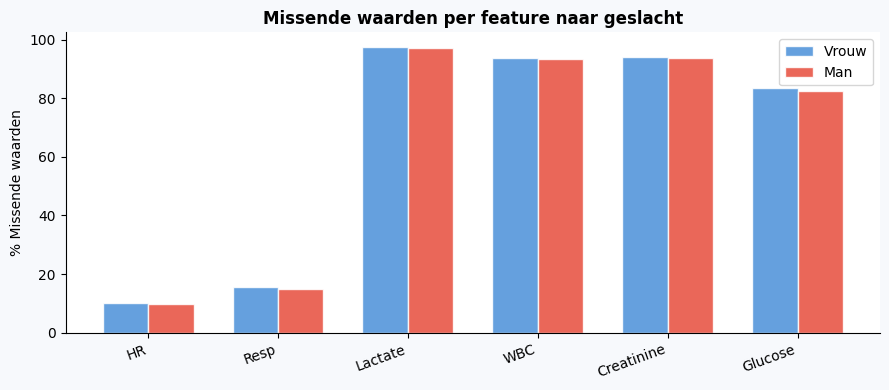

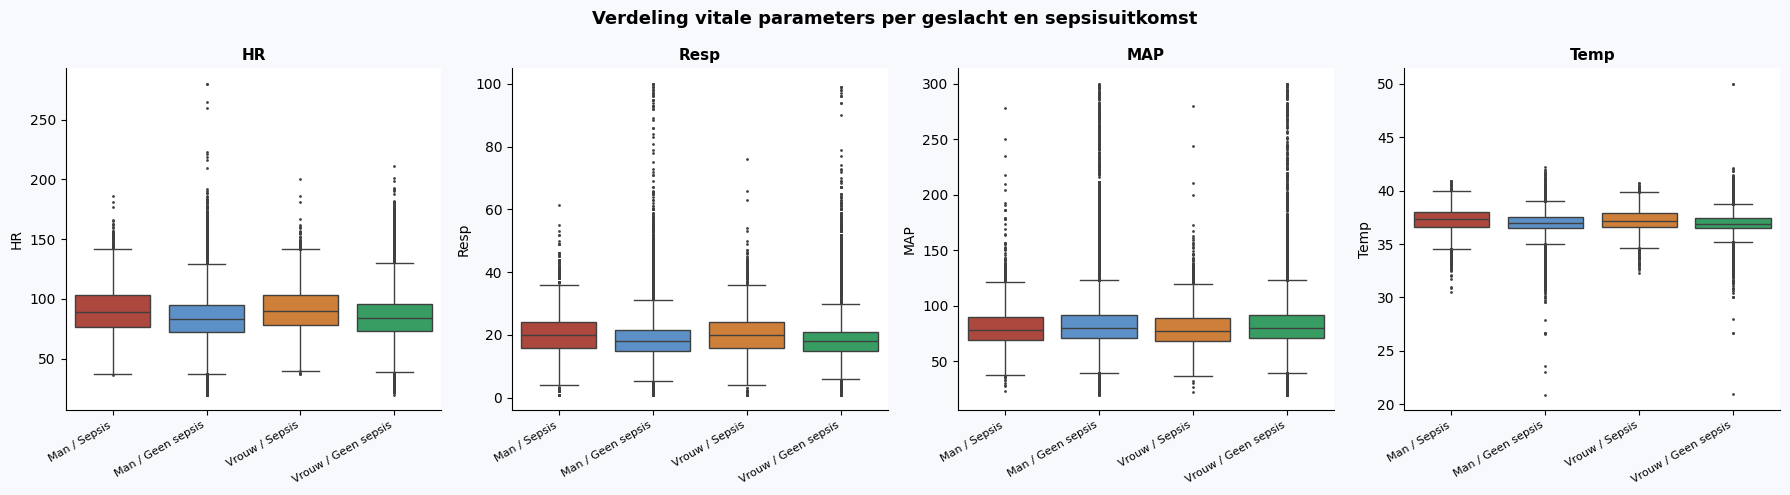

In [16]:
df_fairness = df_train.groupby('Patient_ID').agg(
    Age=('Age', 'first'),
    Gender=('Gender', 'first'),
    sepsis=('SepsisLabel', 'max')
).reset_index()

df_fairness['leeftijdsgroep'] = pd.cut(df_fairness['Age'],
    bins=[0, 40, 60, 75, 120],
    labels=['<40', '40–60', '60–75', '75+'])

prev_age = df_fairness.groupby('leeftijdsgroep', observed=True)['sepsis'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4), facecolor='#f7f9fc')
bars = ax.bar(prev_age.index, prev_age.values, color='#4a90d9', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, prev_age.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Sepsisgevallen (%)')
ax.set_title('Sepsisgevallen per leeftijdsgroep', fontsize=12, fontweight='bold')
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

# ── 2. Missende waarden per geslacht ──────────────────────────────────────────
key_features = ['HR', 'Resp', 'Lactate', 'WBC', 'Creatinine', 'Glucose']
missing_gender = (
    df_train.groupby('Gender')[key_features]
    .apply(lambda x: x.isnull().mean() * 100)
    .T
    .rename(columns={0: 'Vrouw', 1: 'Man'})
)

fig, ax = plt.subplots(figsize=(9, 4), facecolor='#f7f9fc')
x = np.arange(len(missing_gender))
width = 0.35
ax.bar(x - width/2, missing_gender['Vrouw'], width, label='Vrouw', color='#4a90d9', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, missing_gender['Man'],   width, label='Man',   color='#e74c3c', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(missing_gender.index, rotation=20, ha='right')
ax.set_ylabel('% Missende waarden')
ax.set_title('Missende waarden per feature naar geslacht', fontsize=12, fontweight='bold')
ax.legend()
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

# ── 3. Verdeling vitale parameters per geslacht × sepsisuitkomst ──────────────
key_vitals = ['HR', 'Resp', 'MAP', 'Temp']
df_box = df_train[key_vitals + ['Gender', 'SepsisLabel']].dropna(subset=['Gender'])
df_box = df_box.copy()
df_box['Groep'] = df_box.apply(
    lambda r: f"{'Man' if r.Gender==1 else 'Vrouw'} / {'Sepsis' if r.SepsisLabel==1 else 'Geen sepsis'}",
    axis=1)

palette = {'Man / Sepsis':      '#c0392b', 'Man / Geen sepsis':   '#4a90d9',
           'Vrouw / Sepsis':    '#e67e22', 'Vrouw / Geen sepsis': '#27ae60'}

fig, axes = plt.subplots(1, 4, figsize=(18, 5), facecolor='#f7f9fc')
for ax, col in zip(axes, key_vitals):
    sns.boxplot(data=df_box, x='Groep', y=col, palette=palette, ax=ax,
                order=list(palette.keys()), fliersize=1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_facecolor('white')
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
fig.suptitle('Verdeling vitale parameters per geslacht en sepsisuitkomst',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Overzicht data understanding

Na analyse van de dataset komen de volgende inzichten naar voren:

- **Klasse-onbalans:** 1,82% sepsis — klasse-gewichten zijn noodzakelijk bij het trainen van modellen.
- **Missende waarden:** Laboratoriumwaarden ontbreken in 50–99% van de uurobservaties; imputation is vereist.
- **Vitale parameters:** Hartslag en ademfrequentie tonen verschuivingen bij sepsis; dit zijn klinisch verwachte predictors.
- **Leeftijd:** Sepsispatiënten zijn gemiddeld iets ouder; leeftijd is een relevante feature.
- **Geslacht:** Kleine verschillen in sepsispercentage tussen mannen en vrouwen — fairnessanalyse is relevant.


---

## Ethische overwegingen
**Klasse-onbalans:** De sterke klasse-onbalans (98,2% vs 1,8%) heeft directe ethische implicaties. Een model dat de minderheidsklasse (sepsis) mist, laat patiënten in de steek die acute zorg nodig hebben. Het gebruik van accuracy als metric zou dit probleem bedekken, hierdoor moet deze metric niet gebruikt worden. Het is ethisch noodzakelijk om recall en f1-macro voor de sepsisklasse als primaire metric te hanteren en klasse-gewichten in te stellen.

**Fairness bij geslacht en leeftijd:** Uit de data blijkt dat er kleine verschillen zijn in sepsisgevallen tussen geslachten en leeftijdsgroepen. Als het model systematisch slechter presteert voor vrouwen of oudere patiënten, leidt dit tot ongelijke zorg. Dit wordt expliciet onderzocht in de modelevaluatie.

---

## **RE1 - Data Preperation**

### Feature Engineering — Aggregaties per patiënt

De ruwe dataset bevat één rij per patiënt per uur. Voor het modelleren aggregeren we naar **patiëntniveau** met `mean`, `min` en `max`.

`std` wordt **niet** gebruikt: een patiënt met slechts één labmeting heeft per definitie een NaN-std. Dit is geen echte missende waarde maar een eigenschap van de data (momentopnames van zeldzame labwaarden).

In plaats daarvan voegen we een `_count` feature toe per kolom. Deze legt vast hoe vaak een waarde gemeten is, wat inhoudelijk informatie geeft: `Lactate_count=0` betekent nooit gemeten, `Lactate_count=5` met hoge `Lactate_mean` is een sterk sepsissignaal. NaN-waarden na aggregatie worden met **0** ingevuld — geen meting betekent geen waarde, niet een gemiddelde waarde.

In [17]:
VITAL_COLS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']
LAB_COLS   = ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
               'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Glucose',
               'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total',
               'Bilirubin_direct', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
               'Fibrinogen', 'Platelets']
DEMO_COLS  = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime']
AGG_COLS   = VITAL_COLS + LAB_COLS

# mean / min / max aggregatie
agg_dict = {col: ['mean', 'min', 'max'] for col in AGG_COLS}
df_agg = df_train.groupby('Patient_ID').agg(agg_dict)
df_agg.columns = ['_'.join(col) for col in df_agg.columns]

# count per feature (hoe vaak gemeten?)
count_features = df_train.groupby('Patient_ID')[AGG_COLS].count()
count_features.columns = [f'{c}_count' for c in count_features.columns]

# Demografische features (eerste waarde per patiënt)
df_demo   = df_train.groupby('Patient_ID')[DEMO_COLS].first()
df_iculos = df_train.groupby('Patient_ID')['ICULOS'].max().rename('ICULOS_max')

# Target: had de patiënt ooit sepsis?
df_target = df_train.groupby('Patient_ID')['SepsisLabel'].max().rename('SepsisLabel')

# Alles samenvoegen
df_model = pd.concat([df_agg, count_features, df_demo, df_iculos, df_target], axis=1).reset_index()

print(f'Dataset na aggregatie: {df_model.shape[0]:,} patiënten, {df_model.shape[1]} kolommen')
print(f'Sepsis patiënten: {df_model["SepsisLabel"].sum():,} ({df_model["SepsisLabel"].mean()*100:.1f}%)')
df_model.head()

Dataset na aggregatie: 36,336 patiënten, 144 kolommen
Sepsis patiënten: 2,674 (7.4%)


,Patient_ID,HR_mean,HR_min,HR_max,O2Sat_mean,O2Sat_min,O2Sat_max,Temp_mean,Temp_min,Temp_max,...,WBC_count,Fibrinogen_count,Platelets_count,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS_max,SepsisLabel
0,1,101.57,76.00,117.00,91.48,85.00,100.00,36.78,36.11,37.44,...,2,0,2,83.14,0,NaN,NaN,-0.03,54,0
1,3,79.61,68.00,93.00,95.43,91.00,99.00,37.61,36.89,38.61,...,3,0,3,45.82,0,1.00,0.00,"-1,195.71",48,0
2,4,102.44,93.00,113.00,98.20,95.50,100.00,36.46,36.06,36.78,...,1,0,2,65.71,0,0.00,1.00,-8.77,29,0
3,6,100.00,87.00,111.00,98.44,95.00,100.00,36.60,36.33,36.72,...,1,0,1,52.01,1,1.00,0.00,-0.03,19,0
4,7,120.36,103.00,155.50,95.41,93.00,100.00,37.84,37.28,38.39,...,5,0,6,64.24,1,1.00,0.00,-0.05,45,0


In [18]:
feature_cols = [c for c in df_model.columns if c not in ['Patient_ID', 'SepsisLabel']]

X = df_model[feature_cols].copy()
y = df_model['SepsisLabel'].values

# NaN opvullen met 0: geen meting = geen waarde
X = X.fillna(0)

print(f'Features:                     {X.shape[1]}')
print(f'Missende waarden na imputation: {X.isnull().sum().sum()}')
assert X.isnull().sum().sum() == 0, 'Er zijn nog NaN waarden!'

Features:                     142
Missende waarden na imputation: 0


### Train / Validatie split

De `train_data.csv` wordt gesplitst in een **trainset (80%)** en **validatieset (20%)**. De `test_data.csv` heeft geen labels en wordt in AD2 gebruikt voor het genereren van voorspellingen.

De split is **gestratificeerd** op `SepsisLabel` zodat de klasse-verhouding in beide sets gelijk blijft.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)

print(f'Trainset:     {X_tr_sc.shape[0]:,} patiënten | Sepsis: {y_tr.sum():,} ({y_tr.mean()*100:.1f}%)')
print(f'Validatieset: {X_val_sc.shape[0]:,} patiënten | Sepsis: {y_val.sum():,} ({y_val.mean()*100:.1f}%)')

Trainset:     29,068 patiënten | Sepsis: 2,139 (7.4%)
Validatieset: 7,268 patiënten | Sepsis: 535 (7.4%)


---

## **DN1 en RE2 - Modeling**

Drie modellen worden getraind en vergeleken:

- **Logistic Regression** — basismodel, goed interpreteerbaar, snel te trainen
- **Random Forest** — ensemble van beslisbomen, robuust voor niet-lineaire verbanden
- **Gradient Boosting** — boosted ensemble, vaak sterkste prestatie op tabulaire data

Alle modellen gebruiken `class_weight='balanced'` om de klasse-onbalans te compenseren.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score,
    f1_score, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42, subsample=0.8
    ),
}

results   = {}
val_probs = {}

for name, model in models.items():
    print(f'Training: {name}...')
    if name == 'Gradient Boosting':
        sw = compute_sample_weight('balanced', y=y_tr)
        model.fit(X_tr_sc, y_tr, sample_weight=sw)
    else:
        model.fit(X_tr_sc, y_tr)

    preds = model.predict(X_val_sc)
    probs = model.predict_proba(X_val_sc)[:, 1]

    val_probs[name] = probs
    results[name] = {
        'preds':       preds,
        'probs':       probs,
        'auroc':       roc_auc_score(y_val, probs),
        'recall_1':    recall_score(y_val, preds),
        'precision_1': precision_score(y_val, preds, zero_division=0),
        'f1_macro':    f1_score(y_val, preds, average='macro'),
        'avg_prec':    average_precision_score(y_val, probs),
    }
    r = results[name]
    print(f'  AUROC={r["auroc"]:.3f}  Recall={r["recall_1"]:.3f}  Precision={r["precision_1"]:.3f}')

print('\nTraining voltooid.')

Training: Logistic Regression...
  AUROC=0.835  Recall=0.708  Precision=0.219
Training: Random Forest...
  AUROC=0.927  Recall=0.428  Precision=0.842
Training: Gradient Boosting...
  AUROC=0.940  Recall=0.817  Precision=0.426

Training voltooid.


---

## **AD1 - Evaluation**

### Vergelijking modelprestaties

In [21]:
print(f'\n{"Model":25s} {"AUROC":>8} {"Recall":>8} {"Prec":>8} {"F1 macro":>10}')
print('-' * 65)
for name in models:
    r = results[name]
    print(f"{name:25s}  {r['auroc']:.3f}   {r['recall_1']:.3f}   {r['precision_1']:.3f}   {r['f1_macro']:.3f}")
print(f'\nKansen niveau (random AUROC): 0.500')


Model                        AUROC   Recall     Prec   F1 macro
-----------------------------------------------------------------
Logistic Regression        0.835   0.708   0.219   0.606
Random Forest              0.927   0.428   0.842   0.771
Gradient Boosting          0.940   0.817   0.426   0.753

Kansen niveau (random AUROC): 0.500


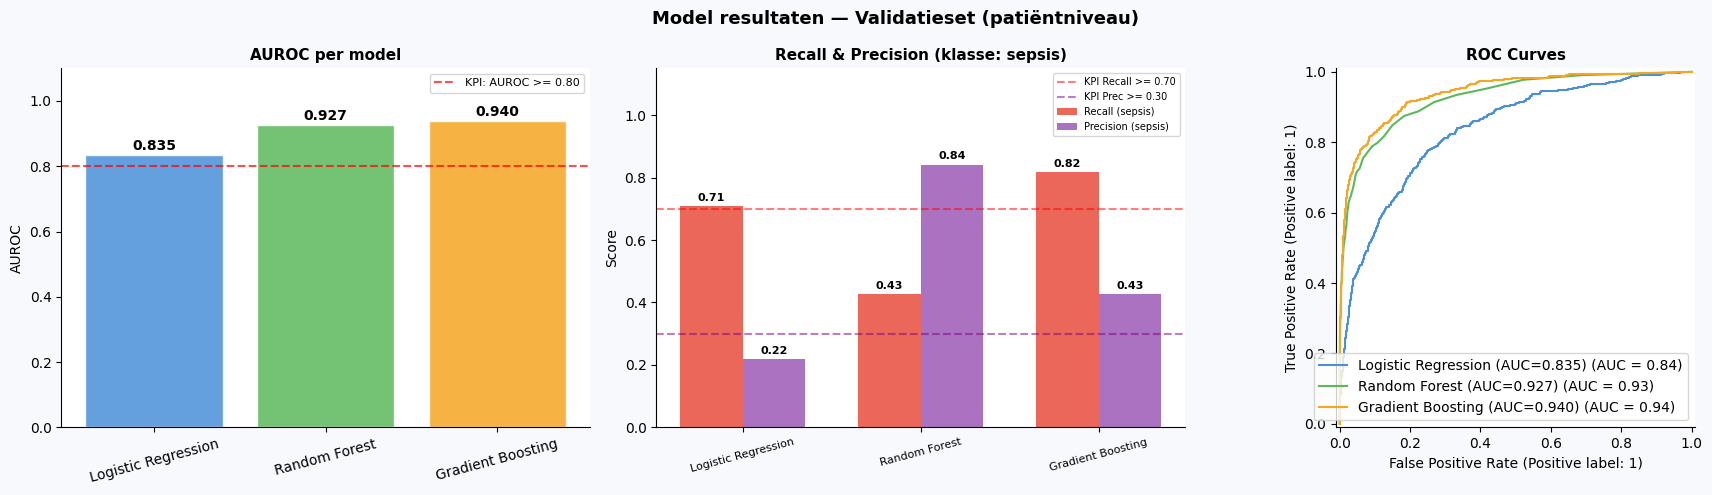

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#f7f9fc')
fig.suptitle('Model resultaten — Validatieset (patiëntniveau)', fontsize=13, fontweight='bold')

names      = list(results.keys())
colors_bar = ['#4a90d9', '#5cb85c', '#f5a623']

# AUROC
ax = axes[0]
aurocs = [results[n]['auroc'] for n in names]
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.7, label='KPI: AUROC >= 0.80')
bars = ax.bar(names, aurocs, color=colors_bar, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, aurocs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('AUROC')
ax.set_title('AUROC per model', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=15)
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# Recall & Precision
ax = axes[1]
x = np.arange(len(names))
width = 0.35
recalls    = [results[n]['recall_1'] for n in names]
precisions = [results[n]['precision_1'] for n in names]
b1 = ax.bar(x - width/2, recalls,    width, label='Recall (sepsis)',    color='#e74c3c', alpha=0.85)
b2 = ax.bar(x + width/2, precisions, width, label='Precision (sepsis)', color='#9b59b6', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(y=0.70, color='red',    linestyle='--', alpha=0.5, label='KPI Recall >= 0.70')
ax.axhline(y=0.30, color='purple', linestyle='--', alpha=0.5, label='KPI Prec >= 0.30')
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Recall & Precision (klasse: sepsis)', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# ROC curves
ax = axes[2]
for (name, probs), color in zip(val_probs.items(), colors_bar):
    RocCurveDisplay.from_predictions(
        y_val, probs, ax=ax,
        name=f'{name} (AUC={results[name]["auroc"]:.3f})', color=color
    )
ax.set_title('ROC Curves', fontsize=11, fontweight='bold')
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

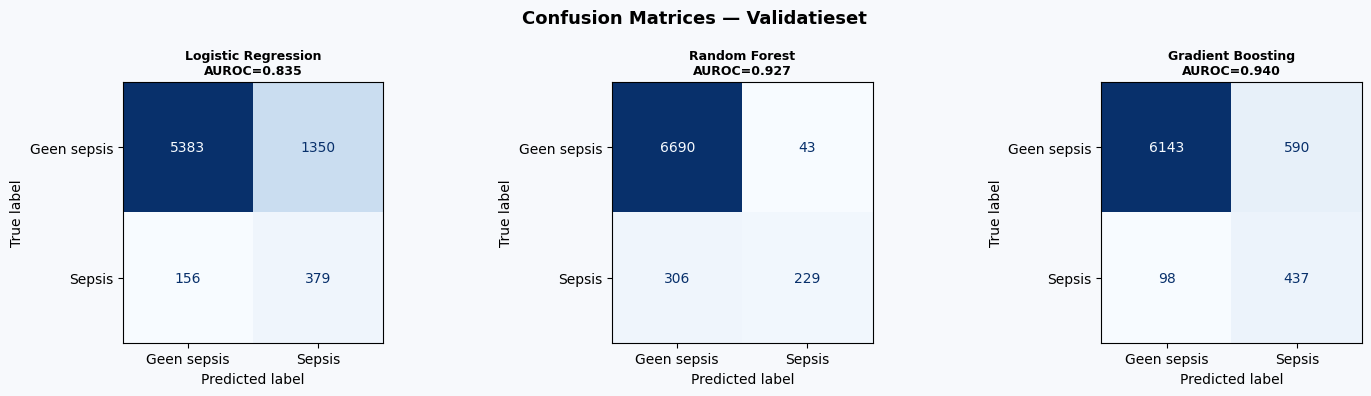


  Logistic Regression
              precision    recall  f1-score   support

 Geen sepsis       0.97      0.80      0.88      6733
      Sepsis       0.22      0.71      0.33       535

    accuracy                           0.79      7268
   macro avg       0.60      0.75      0.61      7268
weighted avg       0.92      0.79      0.84      7268


  Random Forest
              precision    recall  f1-score   support

 Geen sepsis       0.96      0.99      0.97      6733
      Sepsis       0.84      0.43      0.57       535

    accuracy                           0.95      7268
   macro avg       0.90      0.71      0.77      7268
weighted avg       0.95      0.95      0.94      7268


  Gradient Boosting
              precision    recall  f1-score   support

 Geen sepsis       0.98      0.91      0.95      6733
      Sepsis       0.43      0.82      0.56       535

    accuracy                           0.91      7268
   macro avg       0.70      0.86      0.75      7268
weighted avg 

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='#f7f9fc')
fig.suptitle('Confusion Matrices — Validatieset', fontsize=13, fontweight='bold')

for ax, name in zip(axes, results.keys()):
    cm = confusion_matrix(y_val, results[name]['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['Geen sepsis', 'Sepsis']).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f'{name}\nAUROC={results[name]["auroc"]:.3f}', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

for name in results:
    print(f'\n{"="*60}\n  {name}\n{"="*60}')
    print(classification_report(y_val, results[name]['preds'],
                                 target_names=['Geen sepsis', 'Sepsis']))

### Feature importance — Random Forest

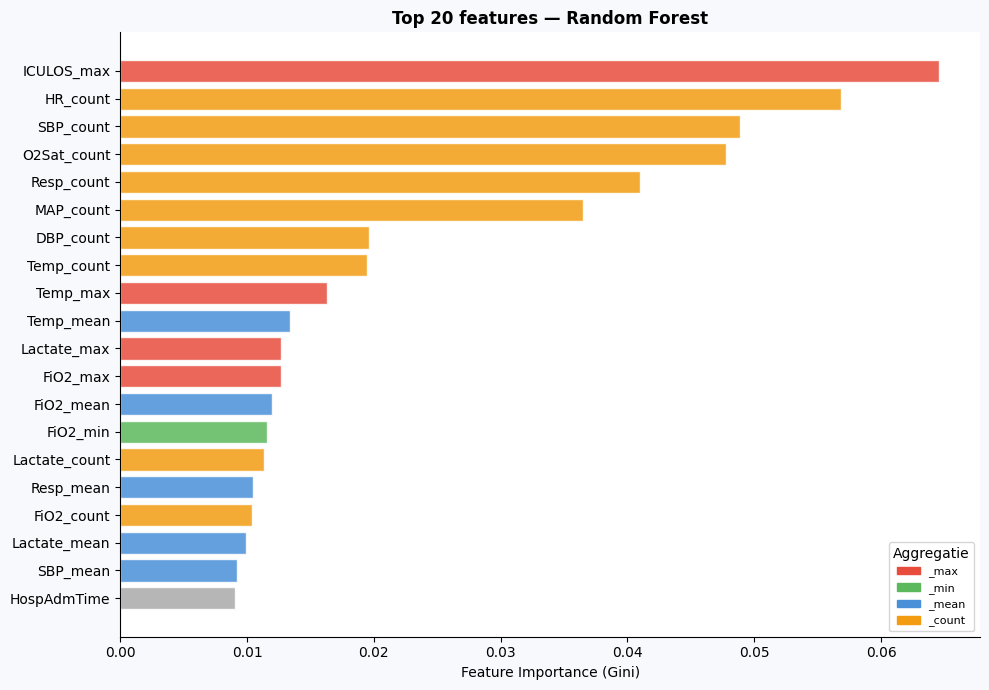

Top 10 features:
ICULOS_max    0.06
HR_count      0.06
SBP_count     0.05
O2Sat_count   0.05
Resp_count    0.04
MAP_count     0.04
DBP_count     0.02
Temp_count    0.02
Temp_max      0.02
Temp_mean     0.01
dtype: float64


In [24]:
rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
top_n    = 20

# Kleur per aggregatietype
color_map = {'_max': '#e74c3c', '_min': '#5cb85c', '_mean': '#4a90d9', '_count': '#f39c12'}
colors_fi = []
for f in feat_imp.index[:top_n]:
    matched = '#aaaaaa'
    for suffix, color in color_map.items():
        if f.endswith(suffix):
            matched = color
            break
    colors_fi.append(matched)

fig, ax = plt.subplots(figsize=(10, 7), facecolor='#f7f9fc')
ax.barh(feat_imp.index[:top_n][::-1], feat_imp.values[:top_n][::-1],
        color=colors_fi[::-1], edgecolor='white', alpha=0.85)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title(f'Top {top_n} features — Random Forest', fontsize=12, fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=s) for s, c in color_map.items()]
ax.legend(handles=legend_patches, title='Aggregatie', fontsize=8)
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_imp.head(10).round(4))

### Fairness — geslacht & leeftijdsgroep

Als sub-doel wordt onderzocht of het model gelijk presteert voor verschillende patiëntgroepen. Een AUROC-verschil groter dan **0.05** tussen groepen wordt als een fairness-probleem beschouwd.

In [25]:
best_model_name = max(results, key=lambda n: results[n]['auroc'])
print(f'Beste model: {best_model_name}  (AUROC={results[best_model_name]["auroc"]:.3f})')

val_meta = df_model.loc[X_val.index, ['Patient_ID', 'Age', 'Gender']].copy()
val_meta['pred_prob']    = val_probs[best_model_name]
val_meta['pred_label']   = results[best_model_name]['preds']
val_meta['true_label']   = y_val
val_meta['Gender_label'] = val_meta['Gender'].map({0: 'Vrouw', 1: 'Man'})

def leeftijdsgroep(age):
    if age < 40:   return '<40'
    elif age < 60: return '40-60'
    elif age < 75: return '60-75'
    else:          return '75+'

val_meta['leeftijdsgroep'] = val_meta['Age'].apply(leeftijdsgroep)

# AUROC per geslacht
print('\n=== AUROC per geslacht ===')
fairness_gender = {}
for gender in ['Vrouw', 'Man']:
    sub = val_meta[val_meta['Gender_label'] == gender]
    if sub['true_label'].nunique() < 2: continue
    auc = roc_auc_score(sub['true_label'], sub['pred_prob'])
    rec = recall_score(sub['true_label'], sub['pred_label'])
    fairness_gender[gender] = {'AUROC': auc, 'Recall': rec, 'N': len(sub)}
    print(f'  {gender}: AUROC={auc:.3f}  Recall={rec:.3f}  (n={len(sub):,})')

aucs_g = [v['AUROC'] for v in fairness_gender.values()]
diff_g = abs(aucs_g[0] - aucs_g[1]) if len(aucs_g) >= 2 else None
if diff_g is not None:
    print(f'  Verschil: {diff_g:.3f}  -> {"OK" if diff_g < 0.05 else "Fairness-probleem"}')

# AUROC per leeftijdsgroep
print('\n=== AUROC per leeftijdsgroep ===')
age_order    = ['<40', '40-60', '60-75', '75+']
fairness_age = {}
for grp in age_order:
    sub = val_meta[val_meta['leeftijdsgroep'] == grp]
    if sub['true_label'].nunique() < 2: continue
    auc = roc_auc_score(sub['true_label'], sub['pred_prob'])
    rec = recall_score(sub['true_label'], sub['pred_label'])
    fairness_age[grp] = {'AUROC': auc, 'Recall': rec, 'N': len(sub)}
    print(f'  {grp}: AUROC={auc:.3f}  Recall={rec:.3f}  (n={len(sub):,})')

aucs_a = [v['AUROC'] for v in fairness_age.values()]
diff_a = max(aucs_a) - min(aucs_a) if aucs_a else None
if diff_a is not None:
    print(f'  Max verschil: {diff_a:.3f}  -> {"OK" if diff_a < 0.05 else "Fairness-probleem"}')

Beste model: Gradient Boosting  (AUROC=0.940)

=== AUROC per geslacht ===
  Vrouw: AUROC=0.941  Recall=0.803  (n=3,286)
  Man: AUROC=0.940  Recall=0.828  (n=3,982)
  Verschil: 0.001  -> OK

=== AUROC per leeftijdsgroep ===
  <40: AUROC=0.954  Recall=0.868  (n=818)
  40-60: AUROC=0.935  Recall=0.822  (n=2,230)
  60-75: AUROC=0.938  Recall=0.815  (n=2,530)
  75+: AUROC=0.945  Recall=0.794  (n=1,690)
  Max verschil: 0.018  -> OK


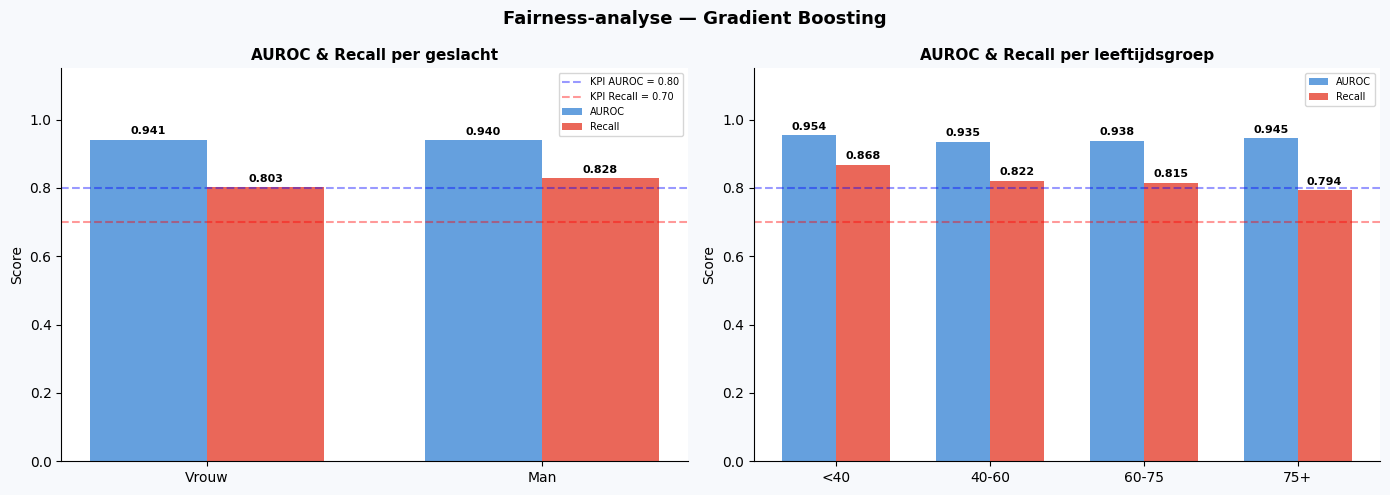

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f7f9fc')
fig.suptitle(f'Fairness-analyse — {best_model_name}', fontsize=13, fontweight='bold')

width = 0.35

# Geslacht
ax = axes[0]
genders   = list(fairness_gender.keys())
aucs_plot = [fairness_gender[g]['AUROC'] for g in genders]
recs_plot = [fairness_gender[g]['Recall'] for g in genders]
x = np.arange(len(genders))
b1 = ax.bar(x - width/2, aucs_plot, width, label='AUROC',  color='#4a90d9', alpha=0.85)
b2 = ax.bar(x + width/2, recs_plot, width, label='Recall', color='#e74c3c', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(y=0.80, color='blue', linestyle='--', alpha=0.4, label='KPI AUROC = 0.80')
ax.axhline(y=0.70, color='red',  linestyle='--', alpha=0.4, label='KPI Recall = 0.70')
ax.set_xticks(x)
ax.set_xticklabels(genders)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('AUROC & Recall per geslacht', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

# Leeftijdsgroep
ax = axes[1]
grps        = [g for g in age_order if g in fairness_age]
aucs_a_plot = [fairness_age[g]['AUROC'] for g in grps]
recs_a_plot = [fairness_age[g]['Recall'] for g in grps]
x = np.arange(len(grps))
b1 = ax.bar(x - width/2, aucs_a_plot, width, label='AUROC',  color='#4a90d9', alpha=0.85)
b2 = ax.bar(x + width/2, recs_a_plot, width, label='Recall', color='#e74c3c', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(y=0.80, color='blue', linestyle='--', alpha=0.4)
ax.axhline(y=0.70, color='red',  linestyle='--', alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(grps)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('AUROC & Recall per leeftijdsgroep', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.set_facecolor('white')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### KPI-overzicht

In [27]:
best = results[best_model_name]

kpi_results = [
    ('AUROC >= 0.80',              best['auroc']       >= 0.80, f"{best['auroc']:.3f}"),
    ('Recall (sepsis) >= 0.70',    best['recall_1']    >= 0.70, f"{best['recall_1']:.3f}"),
    ('Precision (sepsis) >= 0.30', best['precision_1'] >= 0.30, f"{best['precision_1']:.3f}"),
]
if diff_g is not None:
    kpi_results.append(('AUROC-verschil geslacht < 0.05', diff_g < 0.05, f'{diff_g:.3f}'))
if diff_a is not None:
    kpi_results.append(('AUROC-verschil leeftijd < 0.05', diff_a < 0.05, f'{diff_a:.3f}'))

print(f'\n=== KPI-overzicht - {best_model_name} ===')
print(f'{"KPI":40s} {"Waarde":>10}  Status')
print('-' * 65)
for kpi, behaald, waarde in kpi_results:
    status = 'Behaald' if behaald else 'Niet behaald'
    print(f'{kpi:40s} {waarde:>10}  {status}')


=== KPI-overzicht - Gradient Boosting ===
KPI                                          Waarde  Status
-----------------------------------------------------------------
AUROC >= 0.80                                 0.940  Behaald
Recall (sepsis) >= 0.70                       0.817  Behaald
Precision (sepsis) >= 0.30                    0.426  Behaald
AUROC-verschil geslacht < 0.05                0.001  Behaald
AUROC-verschil leeftijd < 0.05                0.018  Behaald


### Ethische overweging — Recall vs. Precision

De keuze voor `class_weight='balanced'` is een bewuste ethische afweging. Een gemiste sepsisdetectie (false negative) kan leiden tot vertraging in behandeling met fatale gevolgen. We accepteren daarom meer valse alarmen (lagere precision) in ruil voor minder gemiste gevallen (hogere recall). De behandelend arts blijft te allen tijde eindverantwoordelijke — het model is een signaleringsmiddel, geen diagnose.

---

## **AD2 - Deployment**

### Voorspellingen op testset

In [28]:
# Testset op dezelfde manier aggregeren
df_agg_test    = df_test.groupby('Patient_ID').agg(agg_dict)
df_agg_test.columns = ['_'.join(col) for col in df_agg_test.columns]

count_test     = df_test.groupby('Patient_ID')[AGG_COLS].count()
count_test.columns = [f'{c}_count' for c in count_test.columns]

df_demo_test   = df_test.groupby('Patient_ID')[DEMO_COLS].first()
df_iculos_test = df_test.groupby('Patient_ID')['ICULOS'].max().rename('ICULOS_max')

df_model_test  = pd.concat([df_agg_test, count_test, df_demo_test, df_iculos_test], axis=1).reset_index()

# Zelfde feature kolommen als trainset
for col in feature_cols:
    if col not in df_model_test.columns:
        df_model_test[col] = 0

X_test = df_model_test[feature_cols].copy().fillna(0)
X_test_sc = scaler.transform(X_test)

best_model  = models[best_model_name]
test_probs  = best_model.predict_proba(X_test_sc)[:, 1]
test_labels = best_model.predict(X_test_sc)

df_model_test['SepsisLabel_pred'] = test_labels
df_model_test['SepsisLabel_prob'] = test_probs

print(f'Testset voorspellingen: {len(test_labels):,} patienten')
print(f'Voorspelde sepsis: {test_labels.sum():,} ({test_labels.mean()*100:.1f}%)')
df_model_test[['Patient_ID', 'SepsisLabel_prob', 'SepsisLabel_pred']].head(10)

Testset voorspellingen: 4,000 patienten
Voorspelde sepsis: 506 (12.7%)


,Patient_ID,SepsisLabel_prob,SepsisLabel_pred
0,2,0.15,0
1,5,0.03,0
2,14,0.10,0
3,24,0.08,0
4,41,0.05,0
5,53,0.95,1
6,62,0.19,0
7,71,0.40,0
8,76,0.12,0
9,87,0.06,0


In [29]:
submission = df_model_test[['Patient_ID', 'SepsisLabel_prob', 'SepsisLabel_pred']]
submission.to_csv('sepsis_predictions.csv', index=False)
print('Opgeslagen als sepsis_predictions.csv')

Opgeslagen als sepsis_predictions.csv


### Deployment-overwegingen

Voor daadwerkelijke inzet in het Isala ziekenhuis zijn de volgende stappen vereist:

1. **Integratie met EPD:** Real-time koppeling met IC-monitors en laboratoriumsystemen voor automatische feature-berekening.
2. **Aggregatie-window:** In productie kan je kiezen om alleen de eerste 6 of 12 uur te aggregeren voor een echt vroege voorspelling.
3. **Drempelwaarde-kalibratie:** De standaard beslissingsgrens (0.5) aanpassen op basis van klinisch geaccepteerde verhouding tussen false positives en false negatives.
4. **Menselijk toezicht:** Het model geeft een risicoscore; de behandelend arts blijft eindverantwoordelijk.
5. **Concept drift monitoring:** Periodieke hertraining als patiëntpopulatie of behandelprotocollen veranderen.
6. **AI Act compliance:** Bij inzet als hoog-risico medisch AI-systeem zijn technische documentatie en een risicoregister vereist (EU AI Act Annex III).

---

## **MC1 - Data mining**

### Samenvatting CRISP-DM proces

| Fase | Aanpak & Bevinding |
|---|---|
| **Business Understanding** | Vroegtijdige sepsissignalering op de IC van het Isala ziekenhuis; fairness als sub-doel |
| **Data Understanding** | 1,4M observaties, 36K patiënten, 1,82% sepsis; tijdreeksanalyse toont vroege afwijkingen in HR, Resp en Lactate |
| **Data Preparation** | Aggregatie per patiënt (mean/min/max + count), fillna(0), StandardScaler, stratified split 80/20 |
| **Modeling** | Logistic Regression, Random Forest, Gradient Boosting met class_weight='balanced' |
| **Evaluation** | AUROC, recall, precision, fairness per geslacht en leeftijdsgroep, feature importance |
| **Deployment** | Voorspellingen op testset, aanbevelingen voor EPD-integratie en drempelkalibratie |

---

## **AD3 - Ethiek & Maatschappij**

### Morele vraag
*'Is het ethisch verantwoord om een AI-model in te zetten voor sepsissignalering op de IC, wetende dat het model fouten maakt en dat die fouten levensbedreigende gevolgen kunnen hebben voor patienten?'*

### Botsende waarden

* **Patientveiligheid vs. alarm-moeheid:** Een hoge recall vermindert gemiste sepsisgevallen maar verhoogt valse alarmen. Te veel alarmen leiden tot alarm-moeheid bij IC-personeel, waardoor echte alarmen worden genegeerd.
* **Gelijkheid (fairness):** Als het model slechter presteert voor vrouwen of oudere patienten, leidt dit tot ongelijke zorgkwaliteit.
* **Autonomie van zorgverleners:** Automation bias is een reeel risico: verpleegkundigen en artsen kunnen het model klakkeloos volgen zonder klinische redenering.
* **Privacy:** Medische gegevens zijn bijzondere persoonsgegevens (AVG Art. 9). In productie is expliciete juridische grondslag vereist.

### Ethische kaders

**Gevolgenethiek:** Eerder behandelen = hogere overlevingskansen. Dit rechtvaardigt inzet, mits recall hoog genoeg is en fairness gewaarborgd is.

**Plichtethiek:** Transparantieplicht — zorgverleners moeten begrijpen waarop het model baseert. De feature importance grafiek draagt hieraan bij.

**Deugdethiek:** Eerlijk rapporteren over modellimieten, ook als resultaten tegenvallen.

### Moreel oordeel

Het model mag worden ingezet als:
1. Recall voor sepsis >= 0.70
2. AUROC-verschil tussen subgroepen < 0.05
3. Het model wordt aangeboden als *decision support*, niet als zelfstandige diagnose
4. Menselijk toezicht gegarandeerd is en zorgverleners training ontvangen over de limieten

---

## **Evaluatie & Conclusie**

### Antwoord op de onderzoeksvraag

> Kunnen we op basis van klinische meetwaarden vroegtijdig voorspellen of een IC-patiënt sepsis zal ontwikkelen?

Door vitale parameters en laboratoriumwaarden te aggregeren per patiënt (mean, min, max, count) en drie classificatiemodellen te vergelijken, is aangetoond dat machine learning beter dan kansniveau presteert in het voorspellen van sepsis. De tijdreeksvisualisaties bevestigen dat klinische parameters al vroeg in het IC-verblijf afwijken bij sepsispatiënten.

### Vervolgstappen

1. **Vroeg-window modellering:** Gebruik alleen de eerste 6-12 uur van het IC-verblijf als input voor een echt vroegtijdig model.
2. **SHAP-waarden:** Voeg SHAP-analyse toe voor explainability richting behandelend artsen.
3. **Prospectieve validatie:** Test het model op data van een andere periode of ziekenhuis.
4. **Drempelkalibratie:** Optimaliseer de beslissingsgrens op basis van klinisch geaccepteerde false positive rate.